# F19: Unconditional Generation & Information Density

**Finding:** Alignment compresses the model's unconditional output below Shannon's English entropy rate (~1.0 bits/char), as measured by an independent byte-level model (BLT 1B). All human text types (fiction, dreams, waking reports, abstracts) remain above this threshold.

**Method:**
1. Generate 100 completions per layer from BOS token only (no prompt) across 10 model families
2. Classify generations by genre (code, exam, prose, template, math) and language
3. Compute self-surprisal (model scoring own output) and reference surprisal (Pythia 1B, BLT 1B)
4. Convert to bits/char using exact character counts per token
5. Compare against human corpora (dreams, fiction, waking reports, academic abstracts)

**Key results:**
- Aligned BOS output: 0.93 bits/char (SFT) to 0.96 (DPO) — below Shannon's 1.0
- Human text: 1.24 (waking) to 1.49 (fiction) — above Shannon's 1.0
- Battery prompts reverse the pattern: alignment *increases* BLT surprisal (displacement/swerve effect)
- Genre confound is real (code ≈ 1.2, template ≈ 2.3) but prose-only analysis preserves all findings
- BOS generation reveals each family's "resting state": OLMo → templates, Llama → Chinese medical exams, Qwen → exam questions in base

In [128]:
import numpy as np
import pandas as pd
from plotnine import *
import plotnine as p9
import warnings
warnings.filterwarnings('ignore')
p9.options.dpi = 300

SHANNON_ENGLISH = 1.0
LAYER_ORDER = ['base', 'ego', 'superego', 'instruct']
LAYER_LABELS = {'base': 'BASE', 'ego': 'SFT', 'superego': 'DPO', 'instruct': 'RLVR'}

## 1. Load generation analysis data

Pre-computed by `scripts/bos_analysis.py` — reads generation cache + surprisal caches, classifies genre, computes bits/char from exact token character counts.

In [129]:
df = pd.read_parquet('../data/generation_analysis.parquet')
print(f'Total generations: {len(df)}')
print(f'Self-surprisal coverage: {df.self_surprisal.notna().sum()}/{len(df)}')
print(f'Ref-surprisal coverage: {df.ref_surprisal.notna().sum()}/{len(df)}')
print(f'Self bits/char coverage: {df.self_bits_per_char.notna().sum()}/{len(df)}')
print(f'\nPrompt types: {df.prompt_type.value_counts().to_dict()}')
print(f'Families: {sorted(df.family.unique())}')
print(f'Layers: {sorted(df.layer.unique())}')
print(f'Genres: {df.genre.value_counts().to_dict()}')

Total generations: 141117
Self-surprisal coverage: 141117/141117
Ref-surprisal coverage: 141117/141117
Self bits/char coverage: 141117/141117

Prompt types: {'battery': 136051, 'the': 2580, 'bos': 2486}
Families: ['amber', 'llama', 'olmo', 'olmo-tiny', 'pythia', 'qwen', 'qwen-tiny', 'smol', 'tulu', 'zephyr']
Layers: ['base', 'ego', 'instruct', 'superego']
Genres: {'prose': 134311, 'exam': 5466, 'template': 719, 'code': 327, 'math': 294}


## 2. Genre distribution of BOS generations

What does each alignment stage "want to say" when given no prompt? Base models produce internet prose; aligned models default to code, templates, and exam questions.

Genre distribution (%) by layer — BOS generations
genre     code  exam  math  prose  template
layer                                      
base       7.8   6.6   2.7   83.0       0.0
ego        6.3   0.4   1.1   72.1      20.2
instruct  15.5   0.0   1.8   82.7       0.0
superego  14.4   5.2   1.1   67.9      11.5


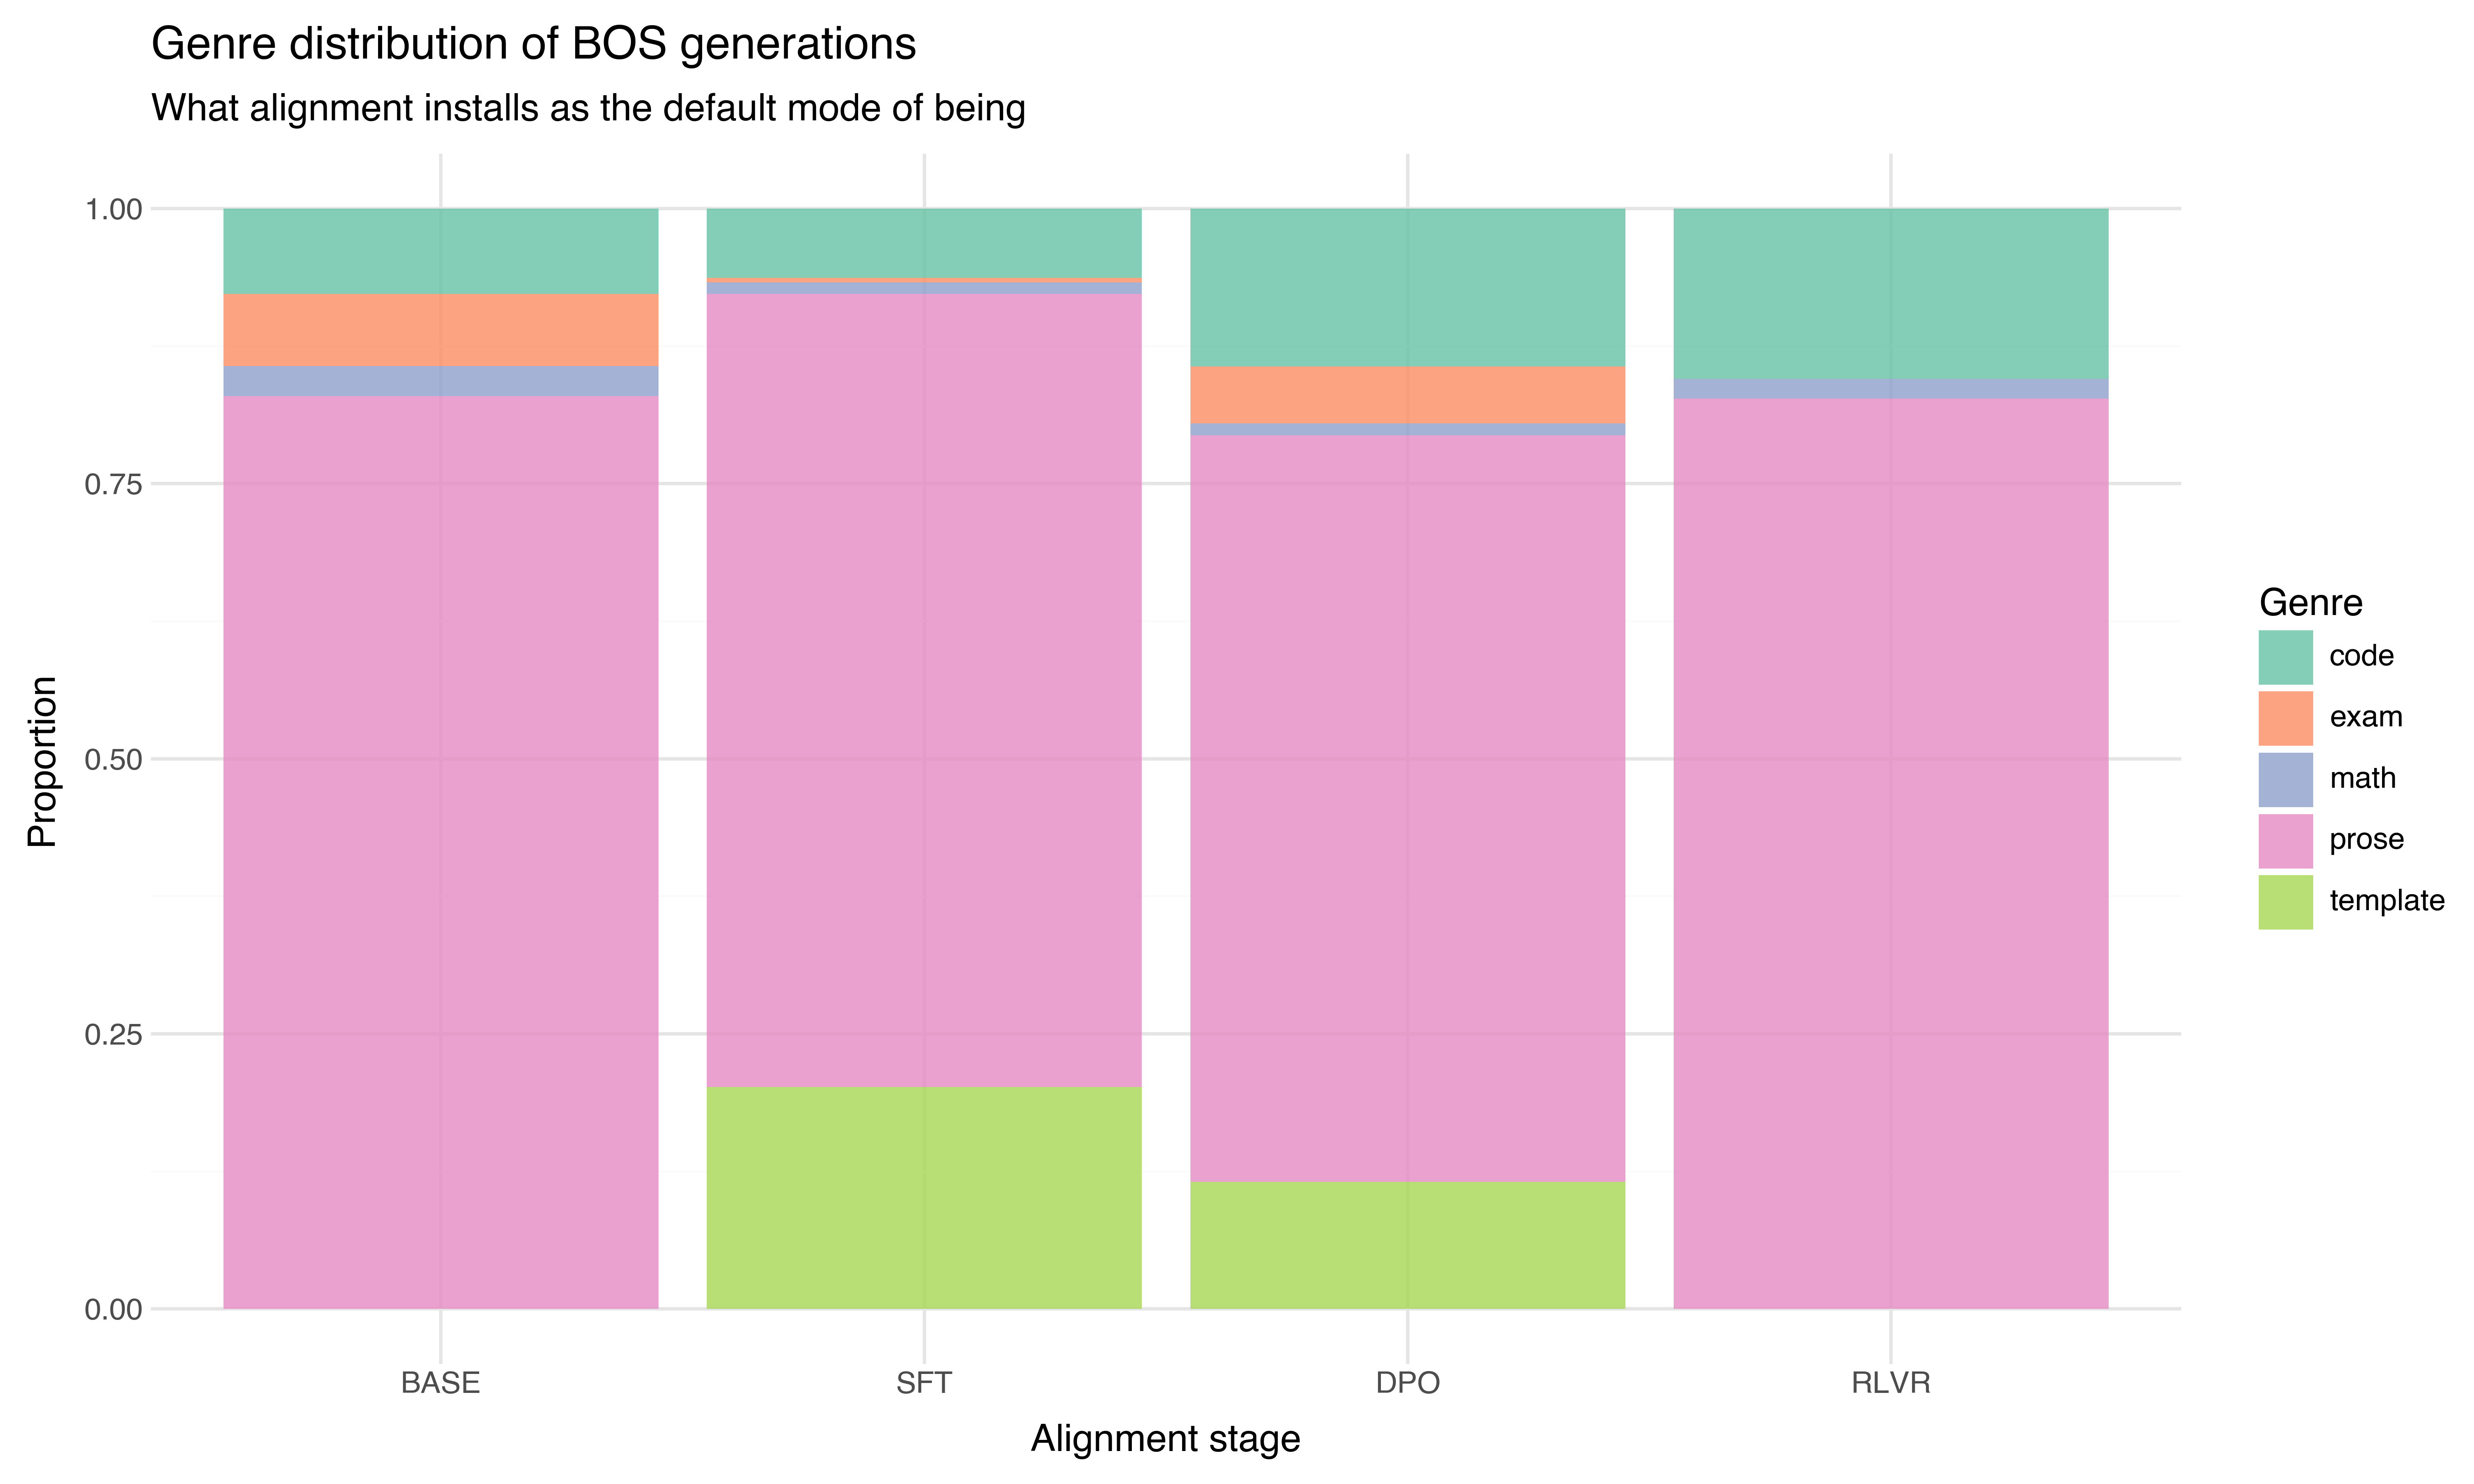

In [130]:
bos = df[df.prompt_type == 'bos'].copy()

# Genre distribution by layer
genre_ct = bos.groupby(['layer', 'genre']).size().unstack(fill_value=0)
genre_pct = genre_ct.div(genre_ct.sum(axis=1), axis=0) * 100
print('Genre distribution (%) by layer — BOS generations')
print(genre_pct.round(1).to_string())

# Plot
genre_long = (bos.groupby(['layer', 'genre']).size()
              .reset_index(name='count'))
genre_long['stage'] = pd.Categorical(
    genre_long['layer'].map(LAYER_LABELS),
    categories=['BASE', 'SFT', 'DPO', 'RLVR'], ordered=True)

fig = (
    ggplot(genre_long.dropna(subset=['stage']),
           aes(x='stage', y='count', fill='genre'))
    + geom_col(position='fill', alpha=0.8)
    + labs(x='Alignment stage', y='Proportion',
           title='Genre distribution of BOS generations',
           subtitle='What alignment installs as the default mode of being',
           fill='Genre')
    + theme_minimal()
    + theme(figure_size=(10, 6))
    + scale_fill_brewer(type='qual', palette='Set2')
)
fig.save('../figures/F19_bos_genre_distribution.png', dpi=300)
fig

In [131]:
# Per-family base layer genre — training data fingerprint
base_bos = bos[bos.layer == 'base']
fam_genre = base_bos.groupby(['family', 'genre']).size().unstack(fill_value=0)
fam_genre_pct = fam_genre.div(fam_genre.sum(axis=1), axis=0) * 100
print('Genre distribution (%) by family — BASE layer BOS')
print(fam_genre_pct.round(1).to_string())

Genre distribution (%) by family — BASE layer BOS
genre      code  exam  math  prose
family                            
amber       3.2   0.0   2.1   94.7
llama       5.0   5.0   0.0   90.0
olmo        9.0   4.0   6.0   81.0
olmo-tiny   0.0   0.0   6.0   94.0
pythia      3.0   0.0   1.0   96.0
qwen       15.0  13.0   6.0   66.0
qwen-tiny  15.0  38.0   4.0   43.0
smol       11.2   0.0   1.0   87.8
tulu        5.0   5.0   0.0   90.0
zephyr     11.0   0.0   1.0   88.0


## 3. Self-surprisal across alignment stages

Self-surprisal measures the model's own channel capacity — how much information per token does the model transmit to itself? Alignment compresses this universally on battery prompts, but BOS reveals family-specific patterns.

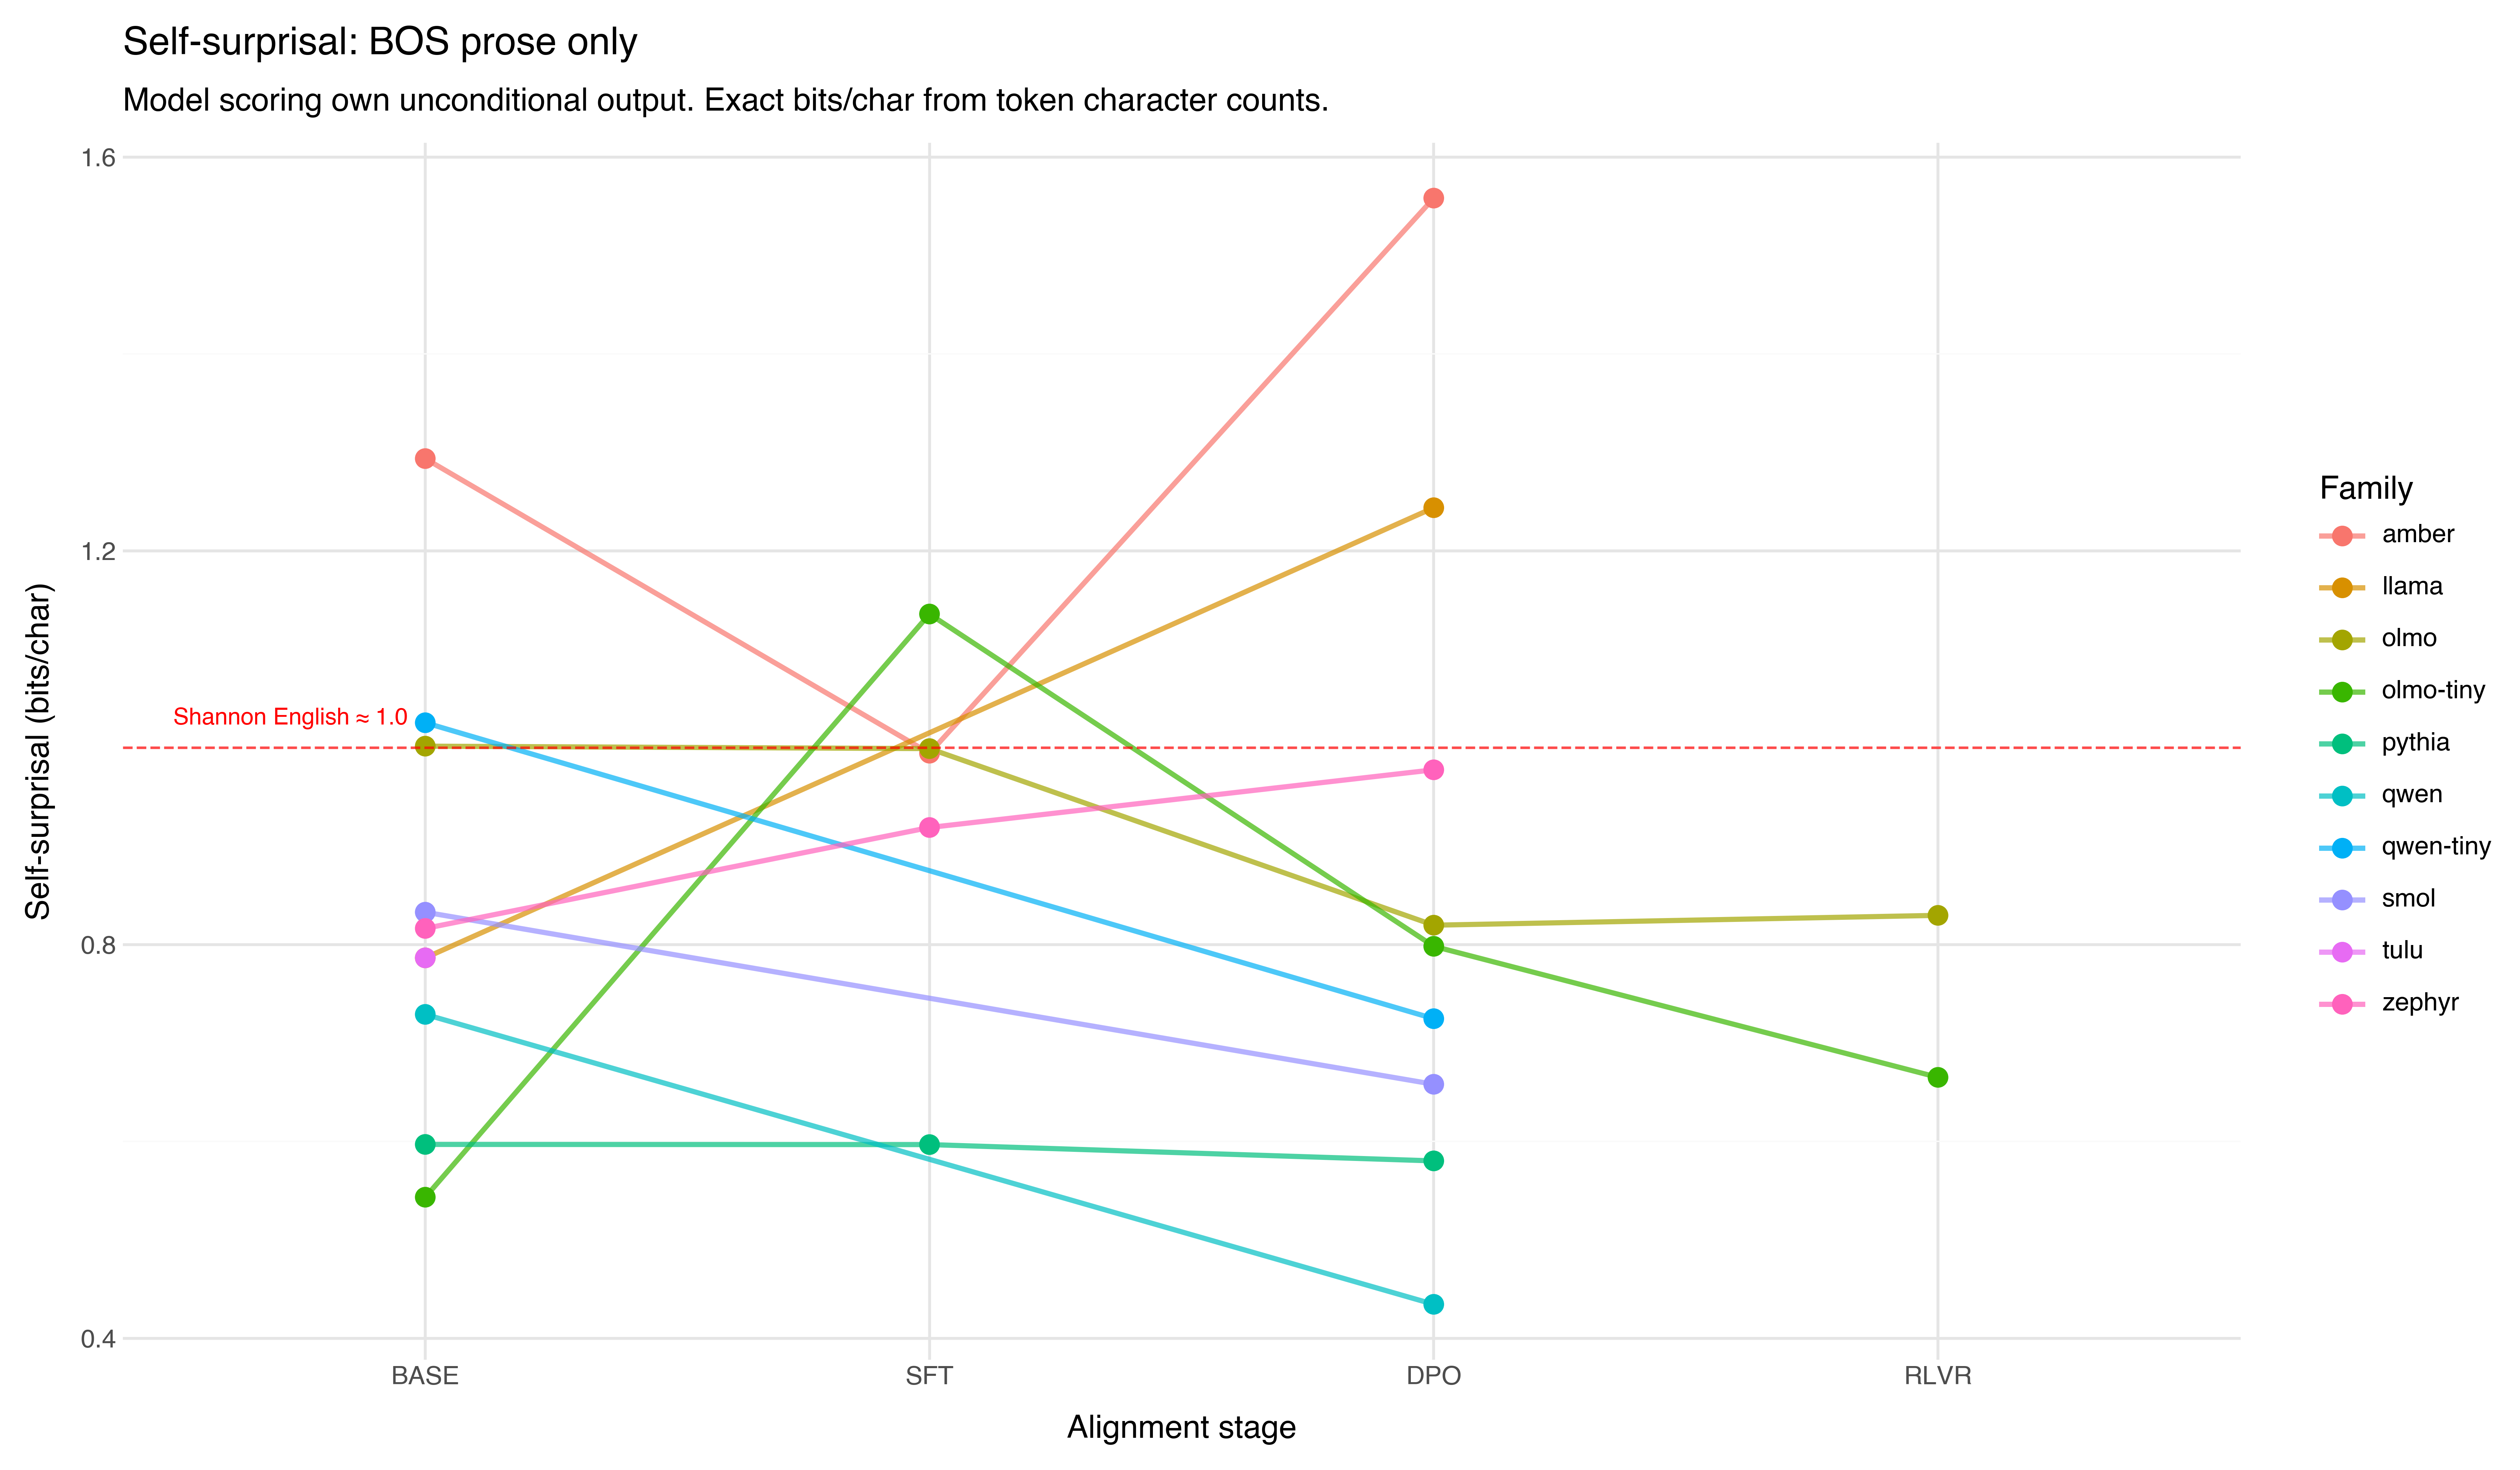

In [132]:
valid = df.dropna(subset=['self_bits_per_char'])

# Self bits/char by family × layer — BOS prose only
bos_prose = valid[(valid.prompt_type == 'bos') & (valid.genre == 'prose')].copy()
bos_prose['stage'] = pd.Categorical(
    bos_prose['layer'].map(LAYER_LABELS),
    categories=['BASE', 'SFT', 'DPO', 'RLVR'], ordered=True)

bos_agg = bos_prose.groupby(['family', 'stage'], observed=True).self_bits_per_char.mean().reset_index()

fig = (
    ggplot(bos_agg, aes(x='stage', y='self_bits_per_char', group='family', color='family'))
    + geom_line(size=1, alpha=0.7)
    + geom_point(size=3)
    + geom_hline(yintercept=SHANNON_ENGLISH, linetype='dashed', color='red', alpha=0.7)
    + annotate('text', x=0.5, y=SHANNON_ENGLISH + 0.03,
               label='Shannon English ≈ 1.0', color='red', size=8, ha='left')
    + labs(x='Alignment stage', y='Self-surprisal (bits/char)',
           title='Self-surprisal: BOS prose only',
           subtitle='Model scoring own unconditional output. Exact bits/char from token character counts.',
           color='Family')
    + theme_minimal()
    + theme(figure_size=(12, 7))
)
fig.save('../figures/F19_self_surprisal_bos_prose.png', dpi=300)
fig

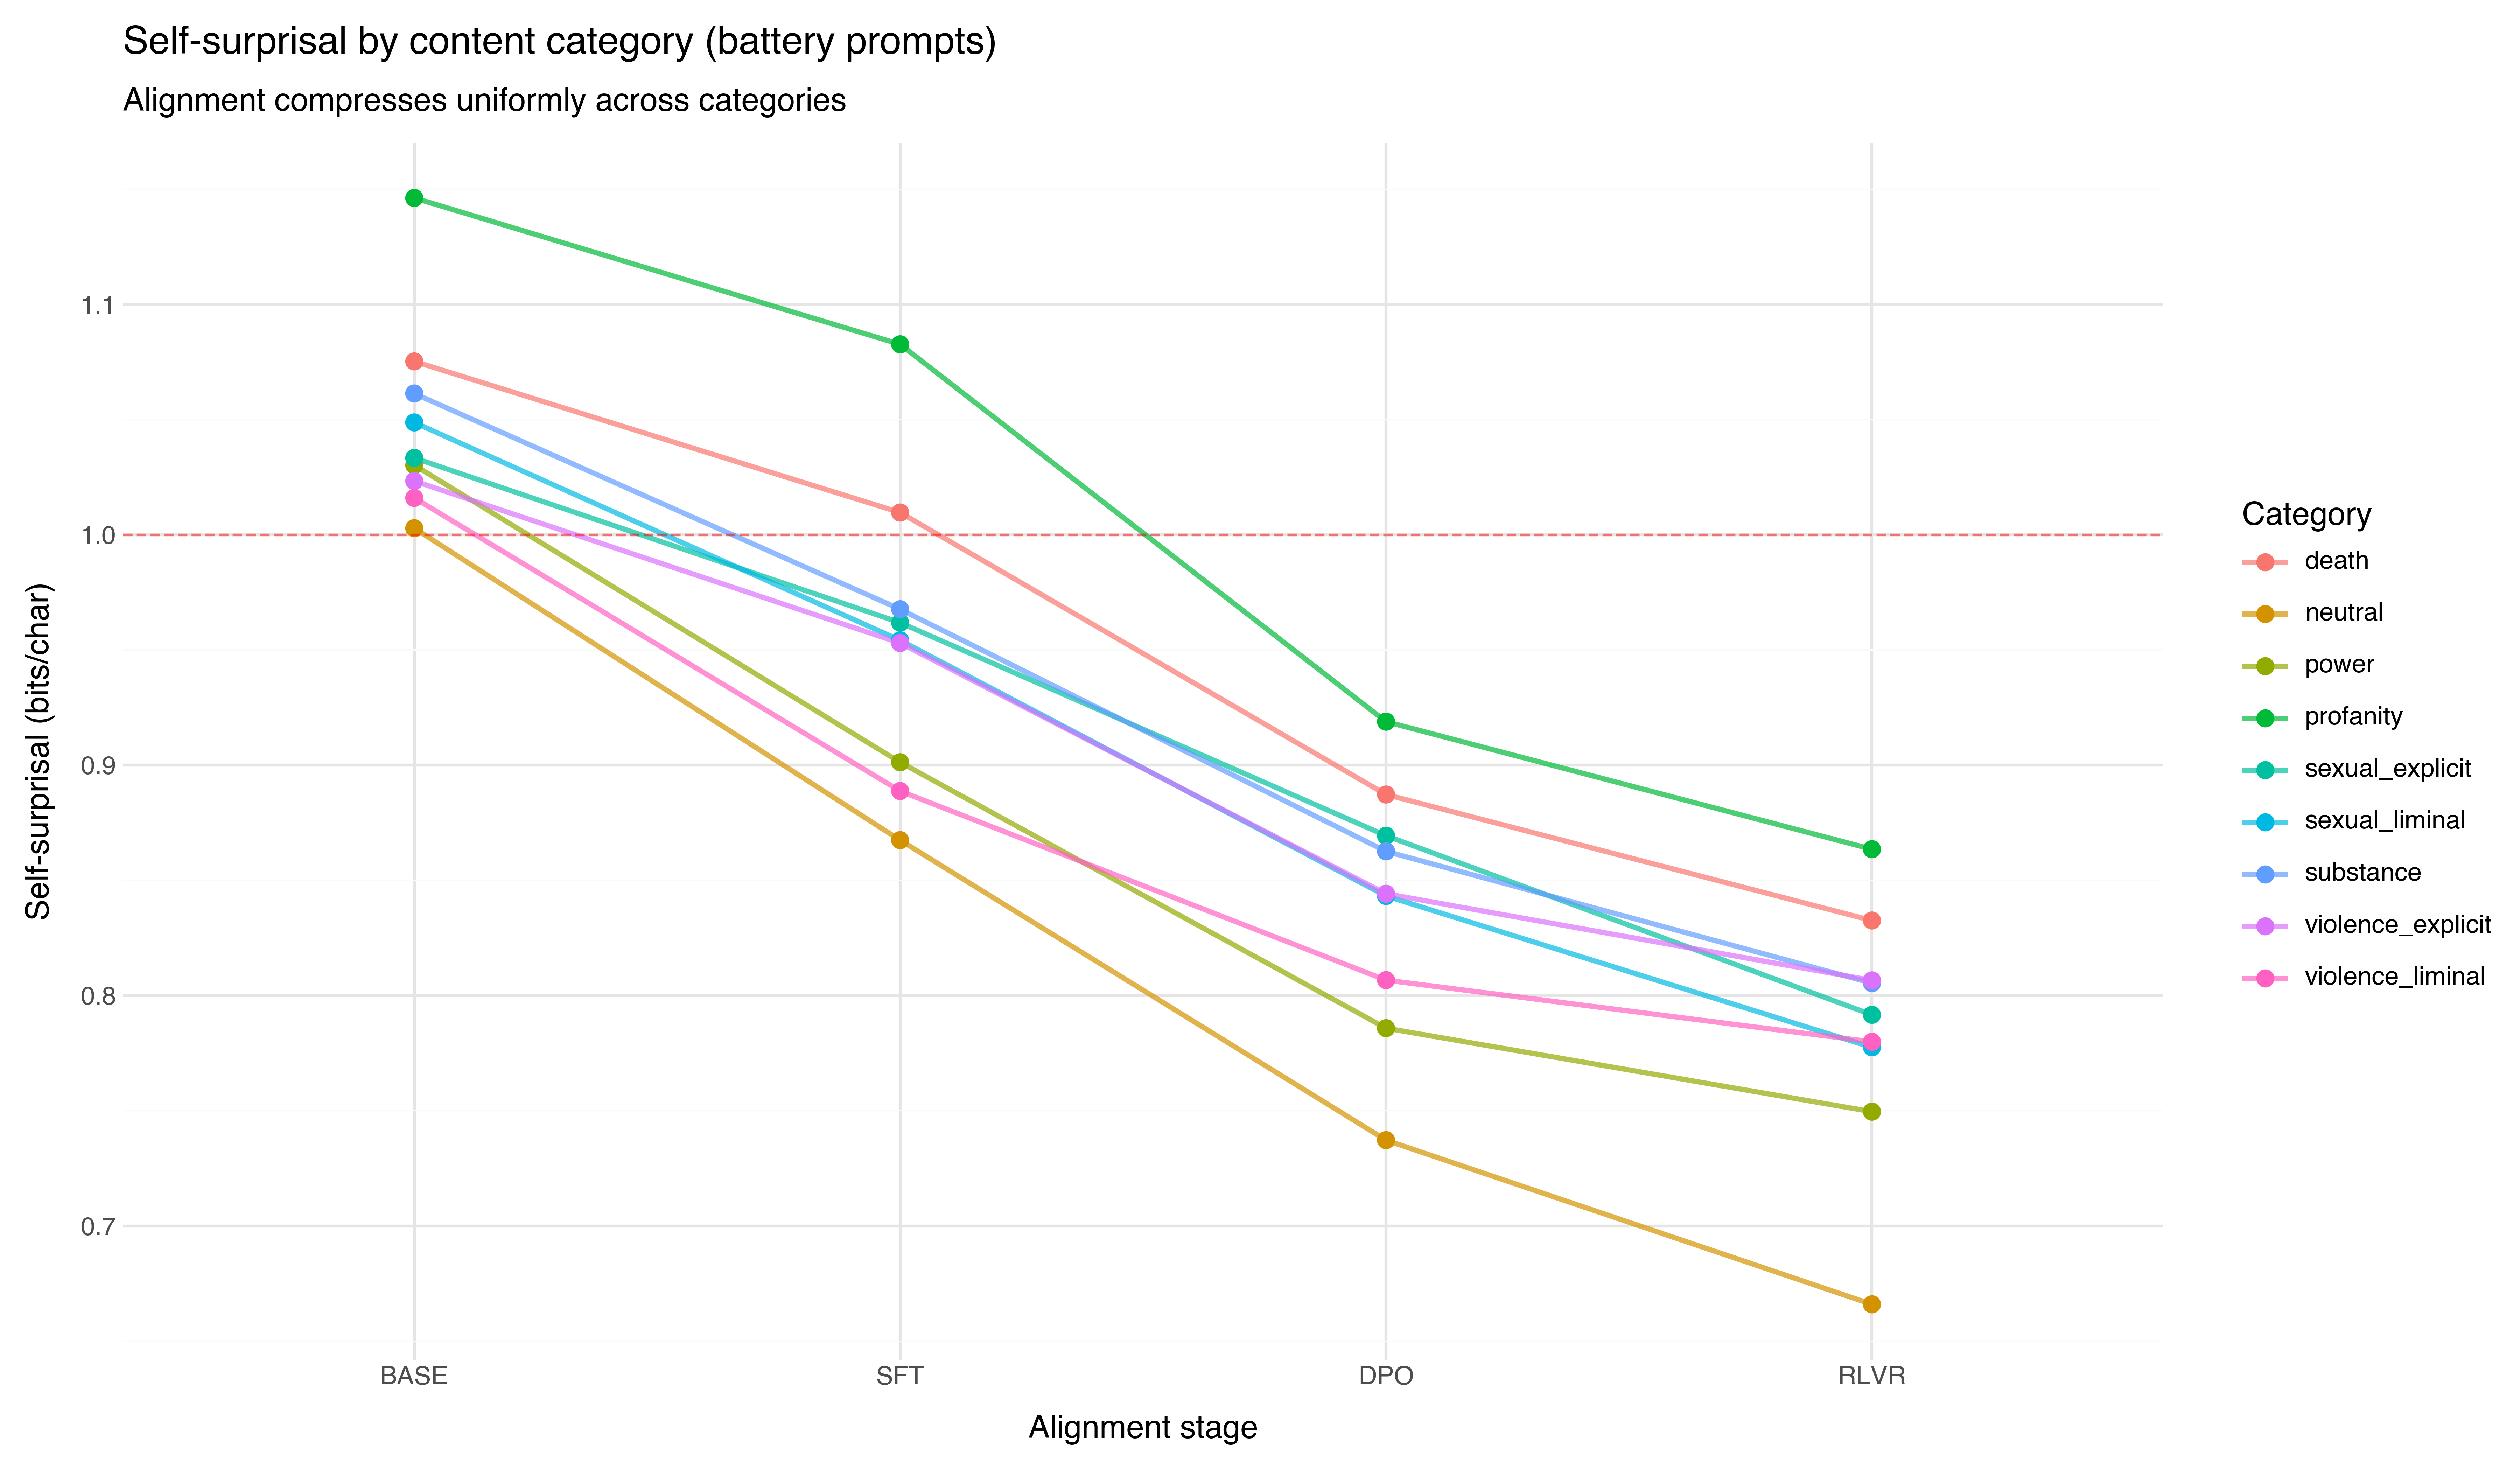

In [133]:
# Battery comparison — self bits/char by category × layer
bat = valid[valid.prompt_type == 'battery'].copy()
bat['stage'] = pd.Categorical(
    bat['layer'].map(LAYER_LABELS),
    categories=['BASE', 'SFT', 'DPO', 'RLVR'], ordered=True)

bat_cat = bat.groupby(['category', 'stage'], observed=True).self_bits_per_char.mean().reset_index()

fig = (
    ggplot(bat_cat, aes(x='stage', y='self_bits_per_char', group='category', color='category'))
    + geom_line(size=1, alpha=0.7)
    + geom_point(size=2.5)
    + geom_hline(yintercept=SHANNON_ENGLISH, linetype='dashed', color='red', alpha=0.5)
    + labs(x='Alignment stage', y='Self-surprisal (bits/char)',
           title='Self-surprisal by content category (battery prompts)',
           subtitle='Alignment compresses uniformly across categories',
           color='Category')
    + theme_minimal()
    + theme(figure_size=(12, 7))
)
fig.save('../figures/F19_self_surprisal_battery_category.png', dpi=300)
fig

## 4. BLT byte-level reference surprisal: human vs AI

BLT (Byte Latent Transformer, 1B) is an independent byte-level model. 1 token = 1 byte ≈ 1 character for ASCII text, so its surprisal is directly in bits/char with no conversion needed. This is the closest analogue to Shannon's measurement: an independent judge scoring text character by character.

Shannon found English at ~1.0 bits/char (his upper bound; true entropy may be lower). All human text types sit above this line. Aligned unconditional output sits below.

In [134]:
# Load human BLT data
human_blt = pd.read_csv('../data/blt_human_corpora.csv').dropna(subset=['blt_bits_per_char'])
human_blt = human_blt.rename(columns={'family': 'source', 'blt_bits_per_char': 'bits_per_char'})
human_blt['group'] = 'Human text'
human_blt['label'] = human_blt['source'].map({
    'dreams': 'Dreams', 'waking': 'Waking',
    'c20_fiction': 'Fiction', 'abstracts': 'Abstracts',
})

print('Human corpora BLT bits/char:')
print(human_blt.groupby('source').bits_per_char.agg(['mean', 'std', 'count']).round(3).to_string())

# Load AI BLT data (from combined CSV if available, otherwise from cache)
try:
    blt_combined = pd.read_csv('../data/blt_combined.csv')
    ai_blt = blt_combined[blt_combined.corpus_type == 'ai']
    print(f'\nAI BLT data: {len(ai_blt)} generations')
    print(f'Families: {sorted(ai_blt.source.unique())}')
except FileNotFoundError:
    print('No blt_combined.csv yet — run scripts/blt_combined.py after BLT finishes')

Human corpora BLT bits/char:
              mean    std  count
source                          
abstracts    1.275  0.340    113
c20_fiction  1.494  0.323    258
dreams       1.322  0.291    227
waking       1.241  0.316    303

AI BLT data: 28728 generations
Families: ['amber', 'llama', 'olmo', 'olmo-tiny', 'pythia', 'qwen', 'qwen-tiny', 'smol', 'tulu', 'zephyr']


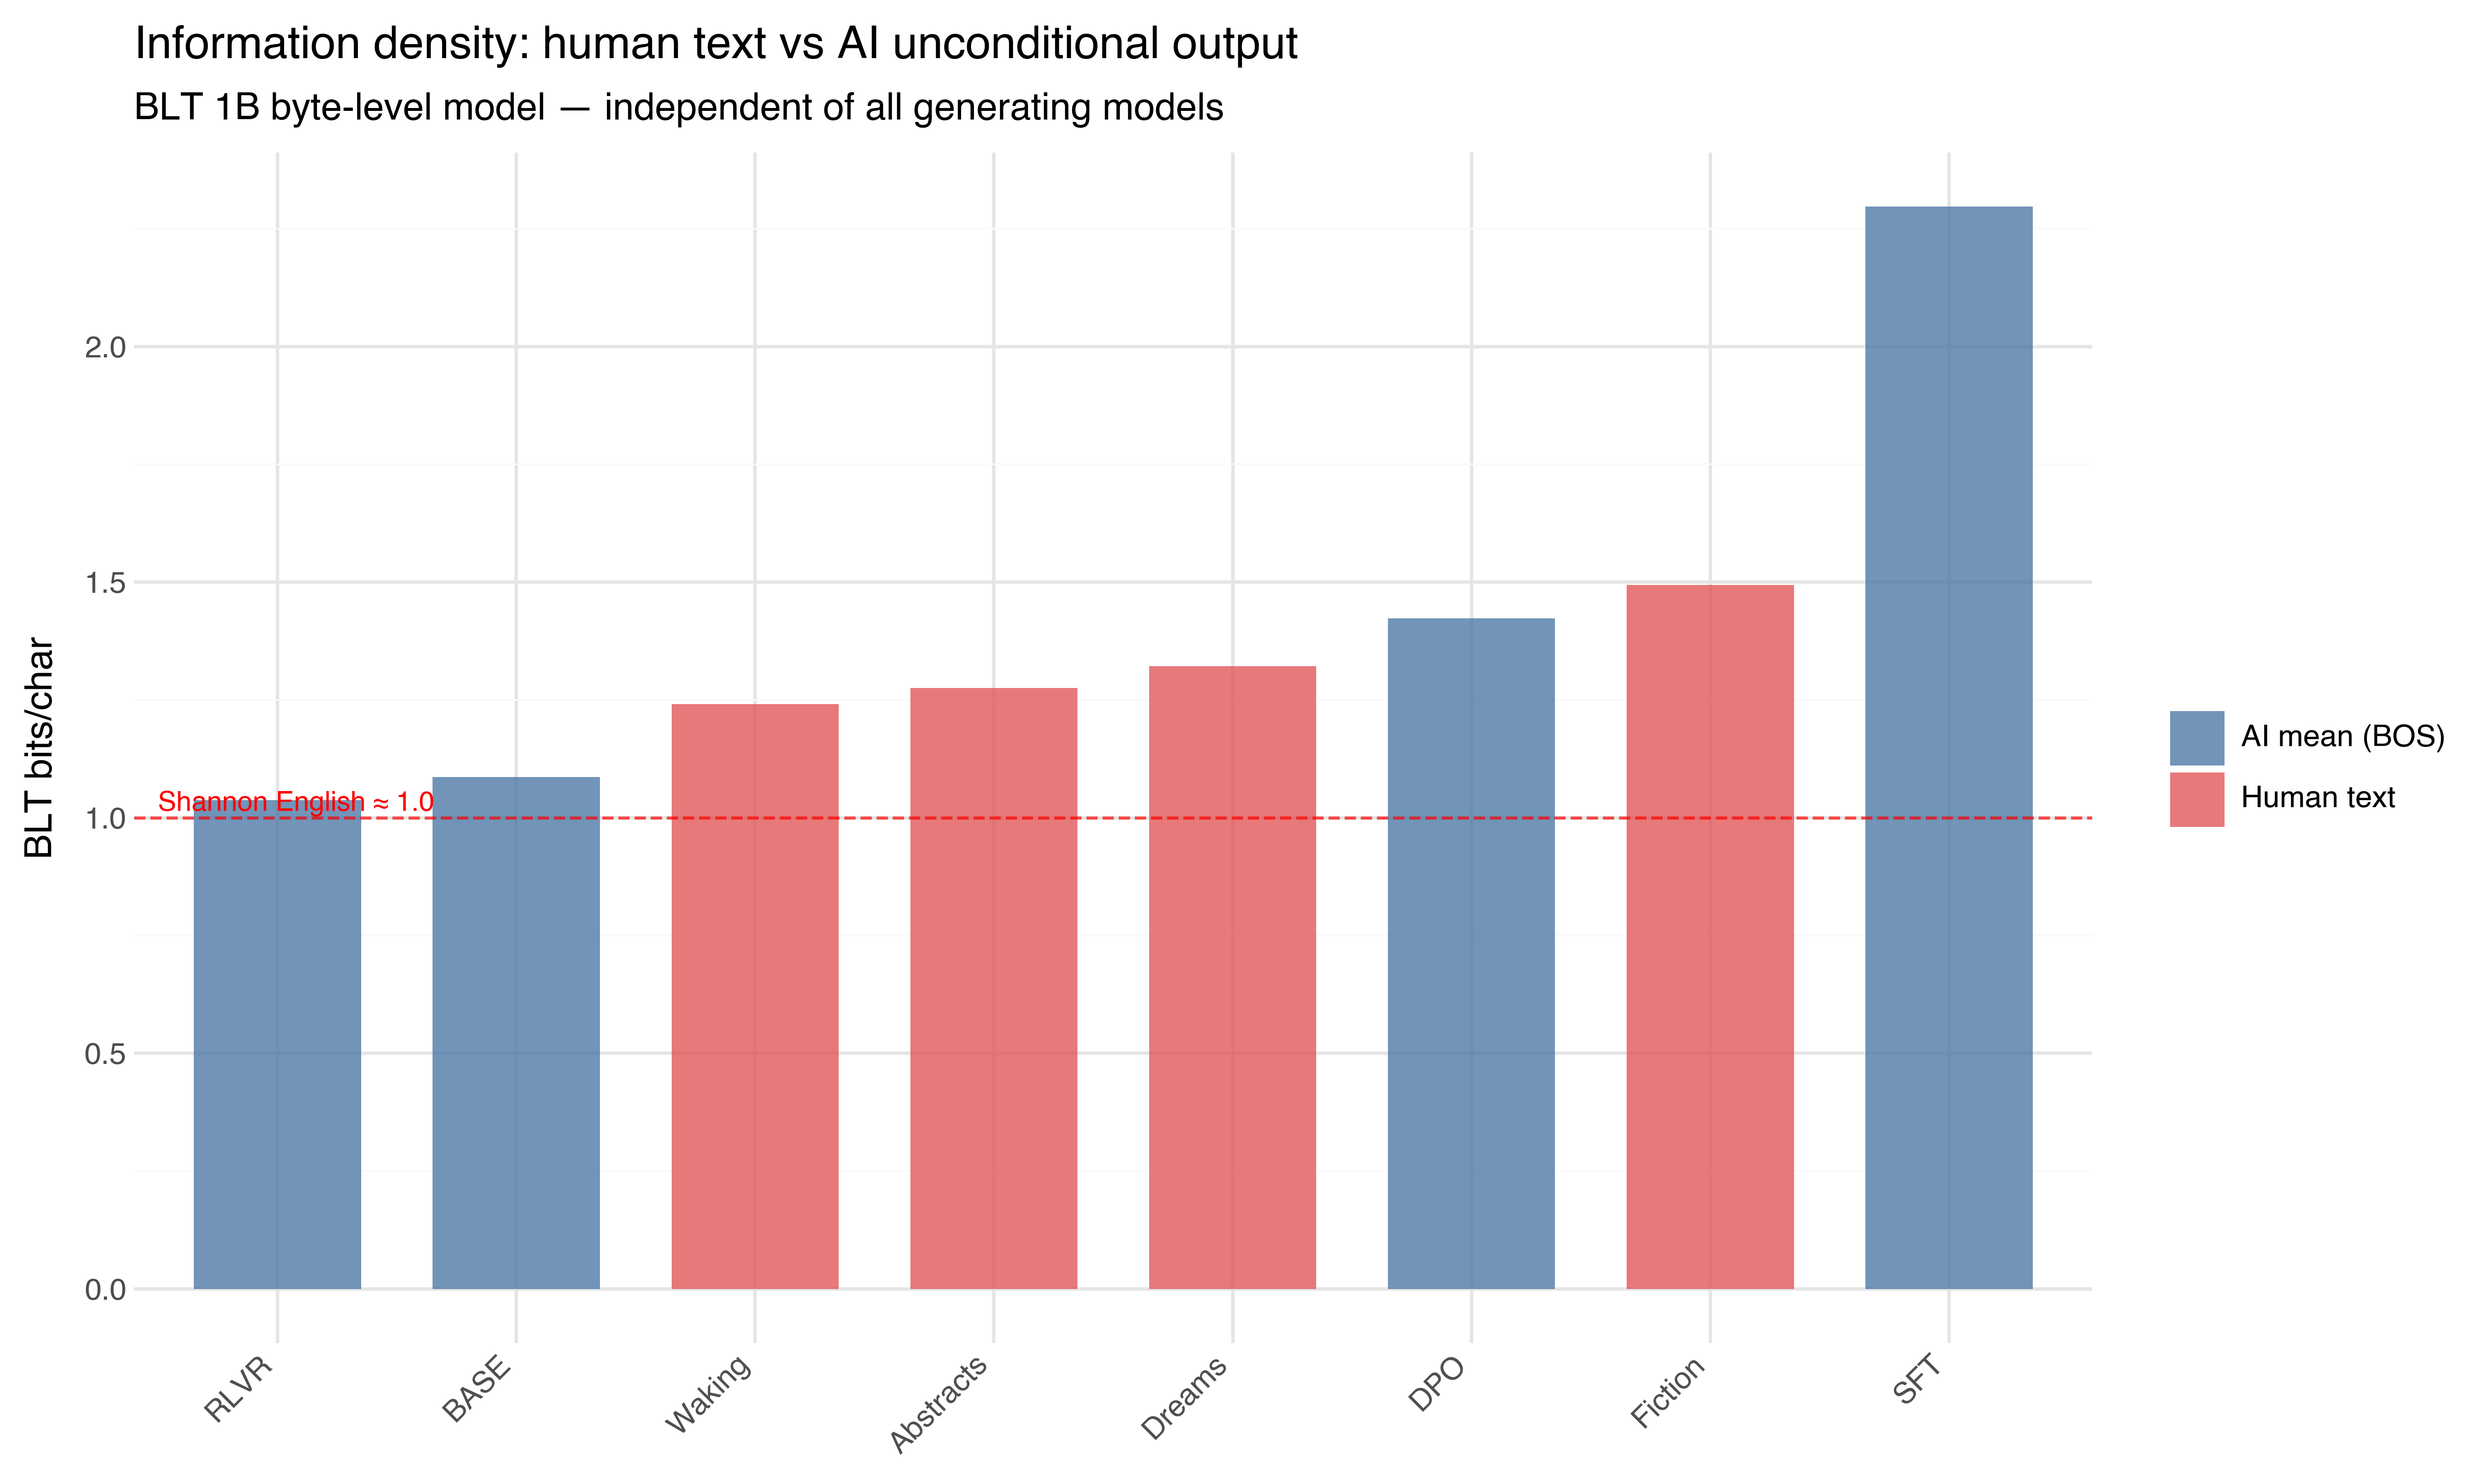

In [142]:
# Combined bar chart: human vs AI (BOS layer means)
human_agg = human_blt.groupby('label').bits_per_char.mean().reset_index()
human_agg['group'] = 'Human text'

ai_bos = ai_blt[ai_blt.prompt_type == 'bos'] if 'ai_blt' in dir() else pd.DataFrame()
layer_means = ai_bos.groupby('layer').bits_per_char.median().reset_index()
layer_means['label'] = layer_means['layer'].map(LAYER_LABELS)
layer_means['group'] = 'AI mean (BOS)'

plot_df = pd.concat([
    human_agg[['label', 'bits_per_char', 'group']],
    layer_means[['label', 'bits_per_char', 'group']],
], ignore_index=True)
plot_df = plot_df.sort_values('bits_per_char')
plot_df['label'] = pd.Categorical(plot_df['label'],
                                    categories=plot_df['label'].tolist(),
                                    ordered=True)

fig = (
    ggplot(plot_df, aes(x='label', y='bits_per_char', fill='group'))
    + geom_col(alpha=0.8, width=0.7)
    + geom_hline(yintercept=SHANNON_ENGLISH, linetype='dashed', color='red', alpha=0.7)
    + annotate('text', x=0.5, y=SHANNON_ENGLISH + 0.03,
                label='Shannon English ≈ 1.0', color='red', size=8, ha='left')
    + labs(x='', y='BLT bits/char',
            title='Information density: human text vs AI unconditional output',
            subtitle='BLT 1B byte-level model — independent of all generating models',
            fill='')
    + theme_minimal()
    + theme(figure_size=(10, 6),
            axis_text_x=element_text(rotation=45, ha='right'))
    + scale_fill_manual(values=['#4e79a7', '#e15759'])
)
fig.save('../figures/F19_blt_human_vs_ai_bos.png', dpi=300)
fig

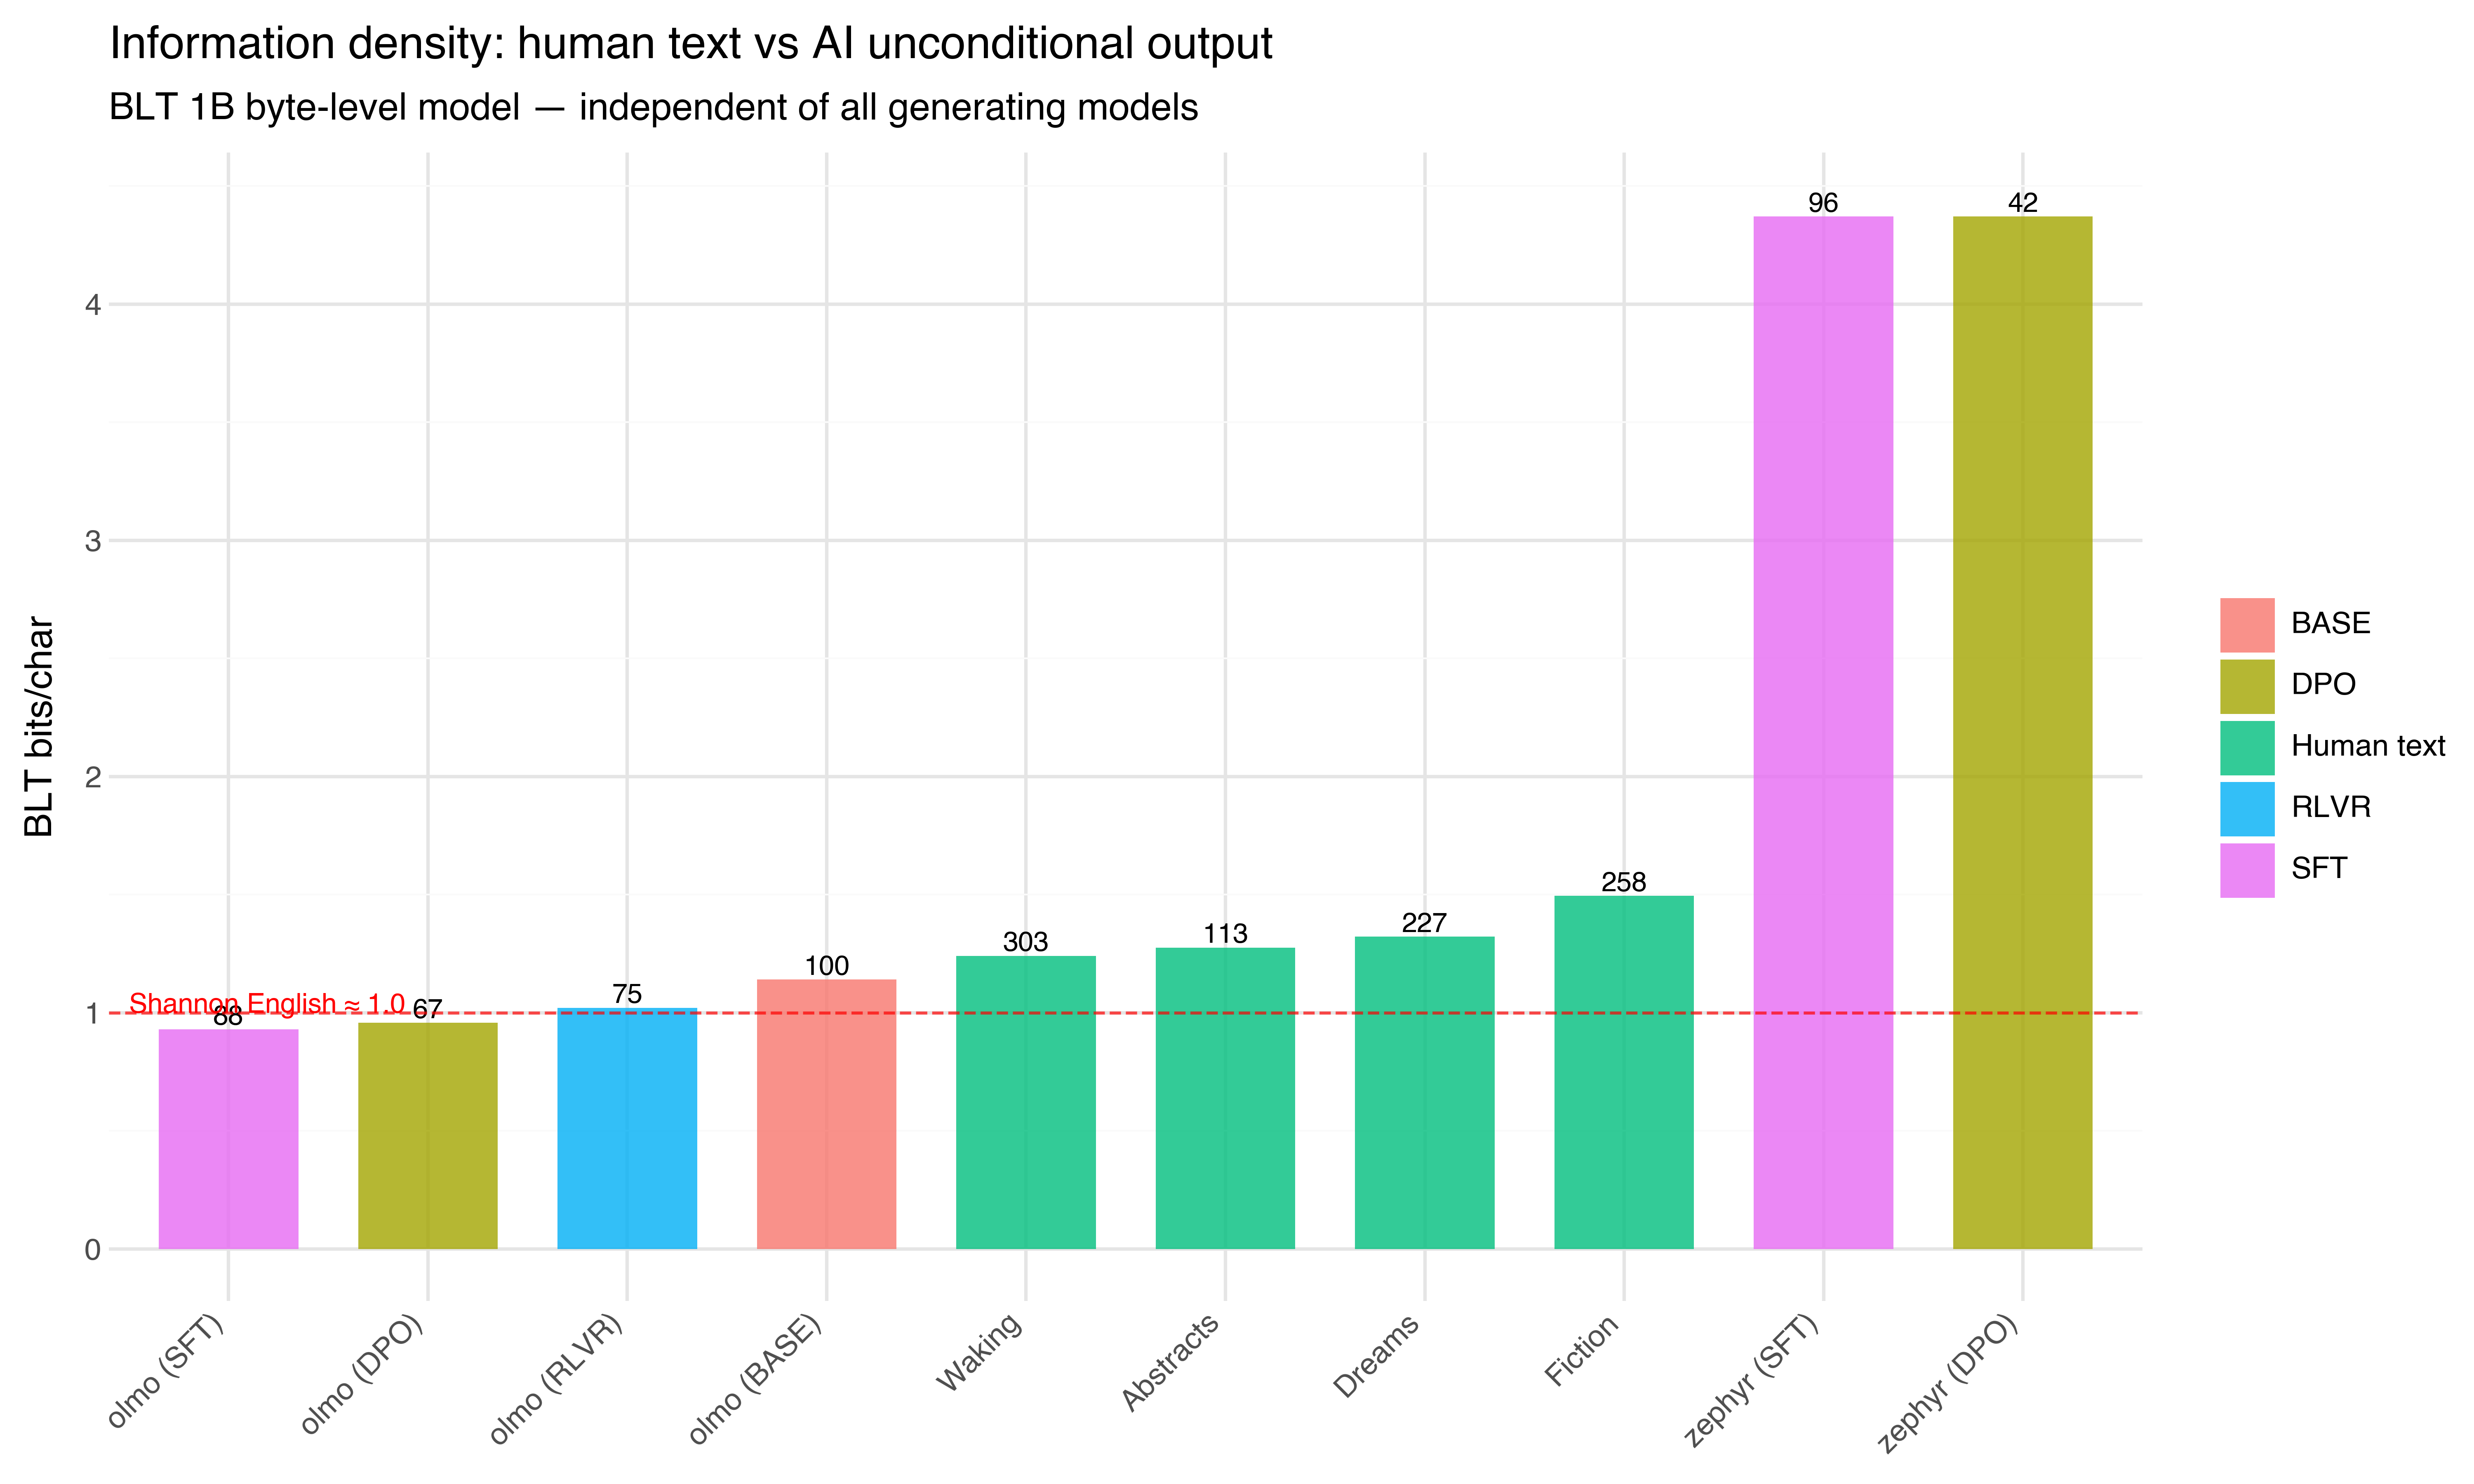

In [136]:
# Combined bar chart: human vs AI (BOS layer means)
human_blt['n']=1
human_agg = human_blt.groupby('label').agg({'bits_per_char':'mean','n':'sum'}).reset_index()
human_agg['group'] = 'Human text'

ai_bos = ai_blt[ai_blt.prompt_type == 'bos'] if 'ai_blt' in dir() else pd.DataFrame()
ai_bos['n']=1
ai_bos = ai_bos[ai_bos['source'] != 'olmo-tiny']

layer_means = ai_bos.groupby(['source','layer']).agg({'bits_per_char':'mean','n':'sum'}).reset_index()
layer_means['label'] = layer_means['source'] + ' (' + layer_means['layer'].map(LAYER_LABELS) + ')'
# layer_means['group'] = 
# layer_means['group'] = 'AI mean (BOS)'
layer_means['group'] = layer_means['layer'].map(LAYER_LABELS)

plot_df = pd.concat([
    human_agg[['label', 'bits_per_char', 'group','n']],
    layer_means[['label', 'bits_per_char', 'group','n']],
], ignore_index=True)
plot_df = plot_df[plot_df['n'] > 10]
plot_df = plot_df.sort_values('bits_per_char')
plot_df['label'] = pd.Categorical(plot_df['label'],
                                    categories=plot_df['label'].tolist(),
                                    ordered=True)

fig = (
    ggplot(plot_df, aes(x='label', y='bits_per_char', fill='group',label='n'))
    + geom_col(alpha=0.8, width=0.7)
    + geom_text(nudge_y=0.05, size=8)
    + geom_hline(yintercept=SHANNON_ENGLISH, linetype='dashed', color='red', alpha=0.7)
    + annotate('text', x=0.5, y=SHANNON_ENGLISH + 0.03,
                label='Shannon English ≈ 1.0', color='red', size=8, ha='left')
    + labs(x='', y='BLT bits/char',
            title='Information density: human text vs AI unconditional output',
            subtitle='BLT 1B byte-level model — independent of all generating models',
            fill='')
    + theme_minimal()
    + theme(figure_size=(10, 6),
            axis_text_x=element_text(rotation=45, ha='right'))
    # + scale_fill_manual(values=['#4e79a7', '#e15759'])
)
fig.save('../figures/F19_blt_human_vs_ai_bos_family_layer.png', dpi=300)
fig

In [137]:
# gen_df

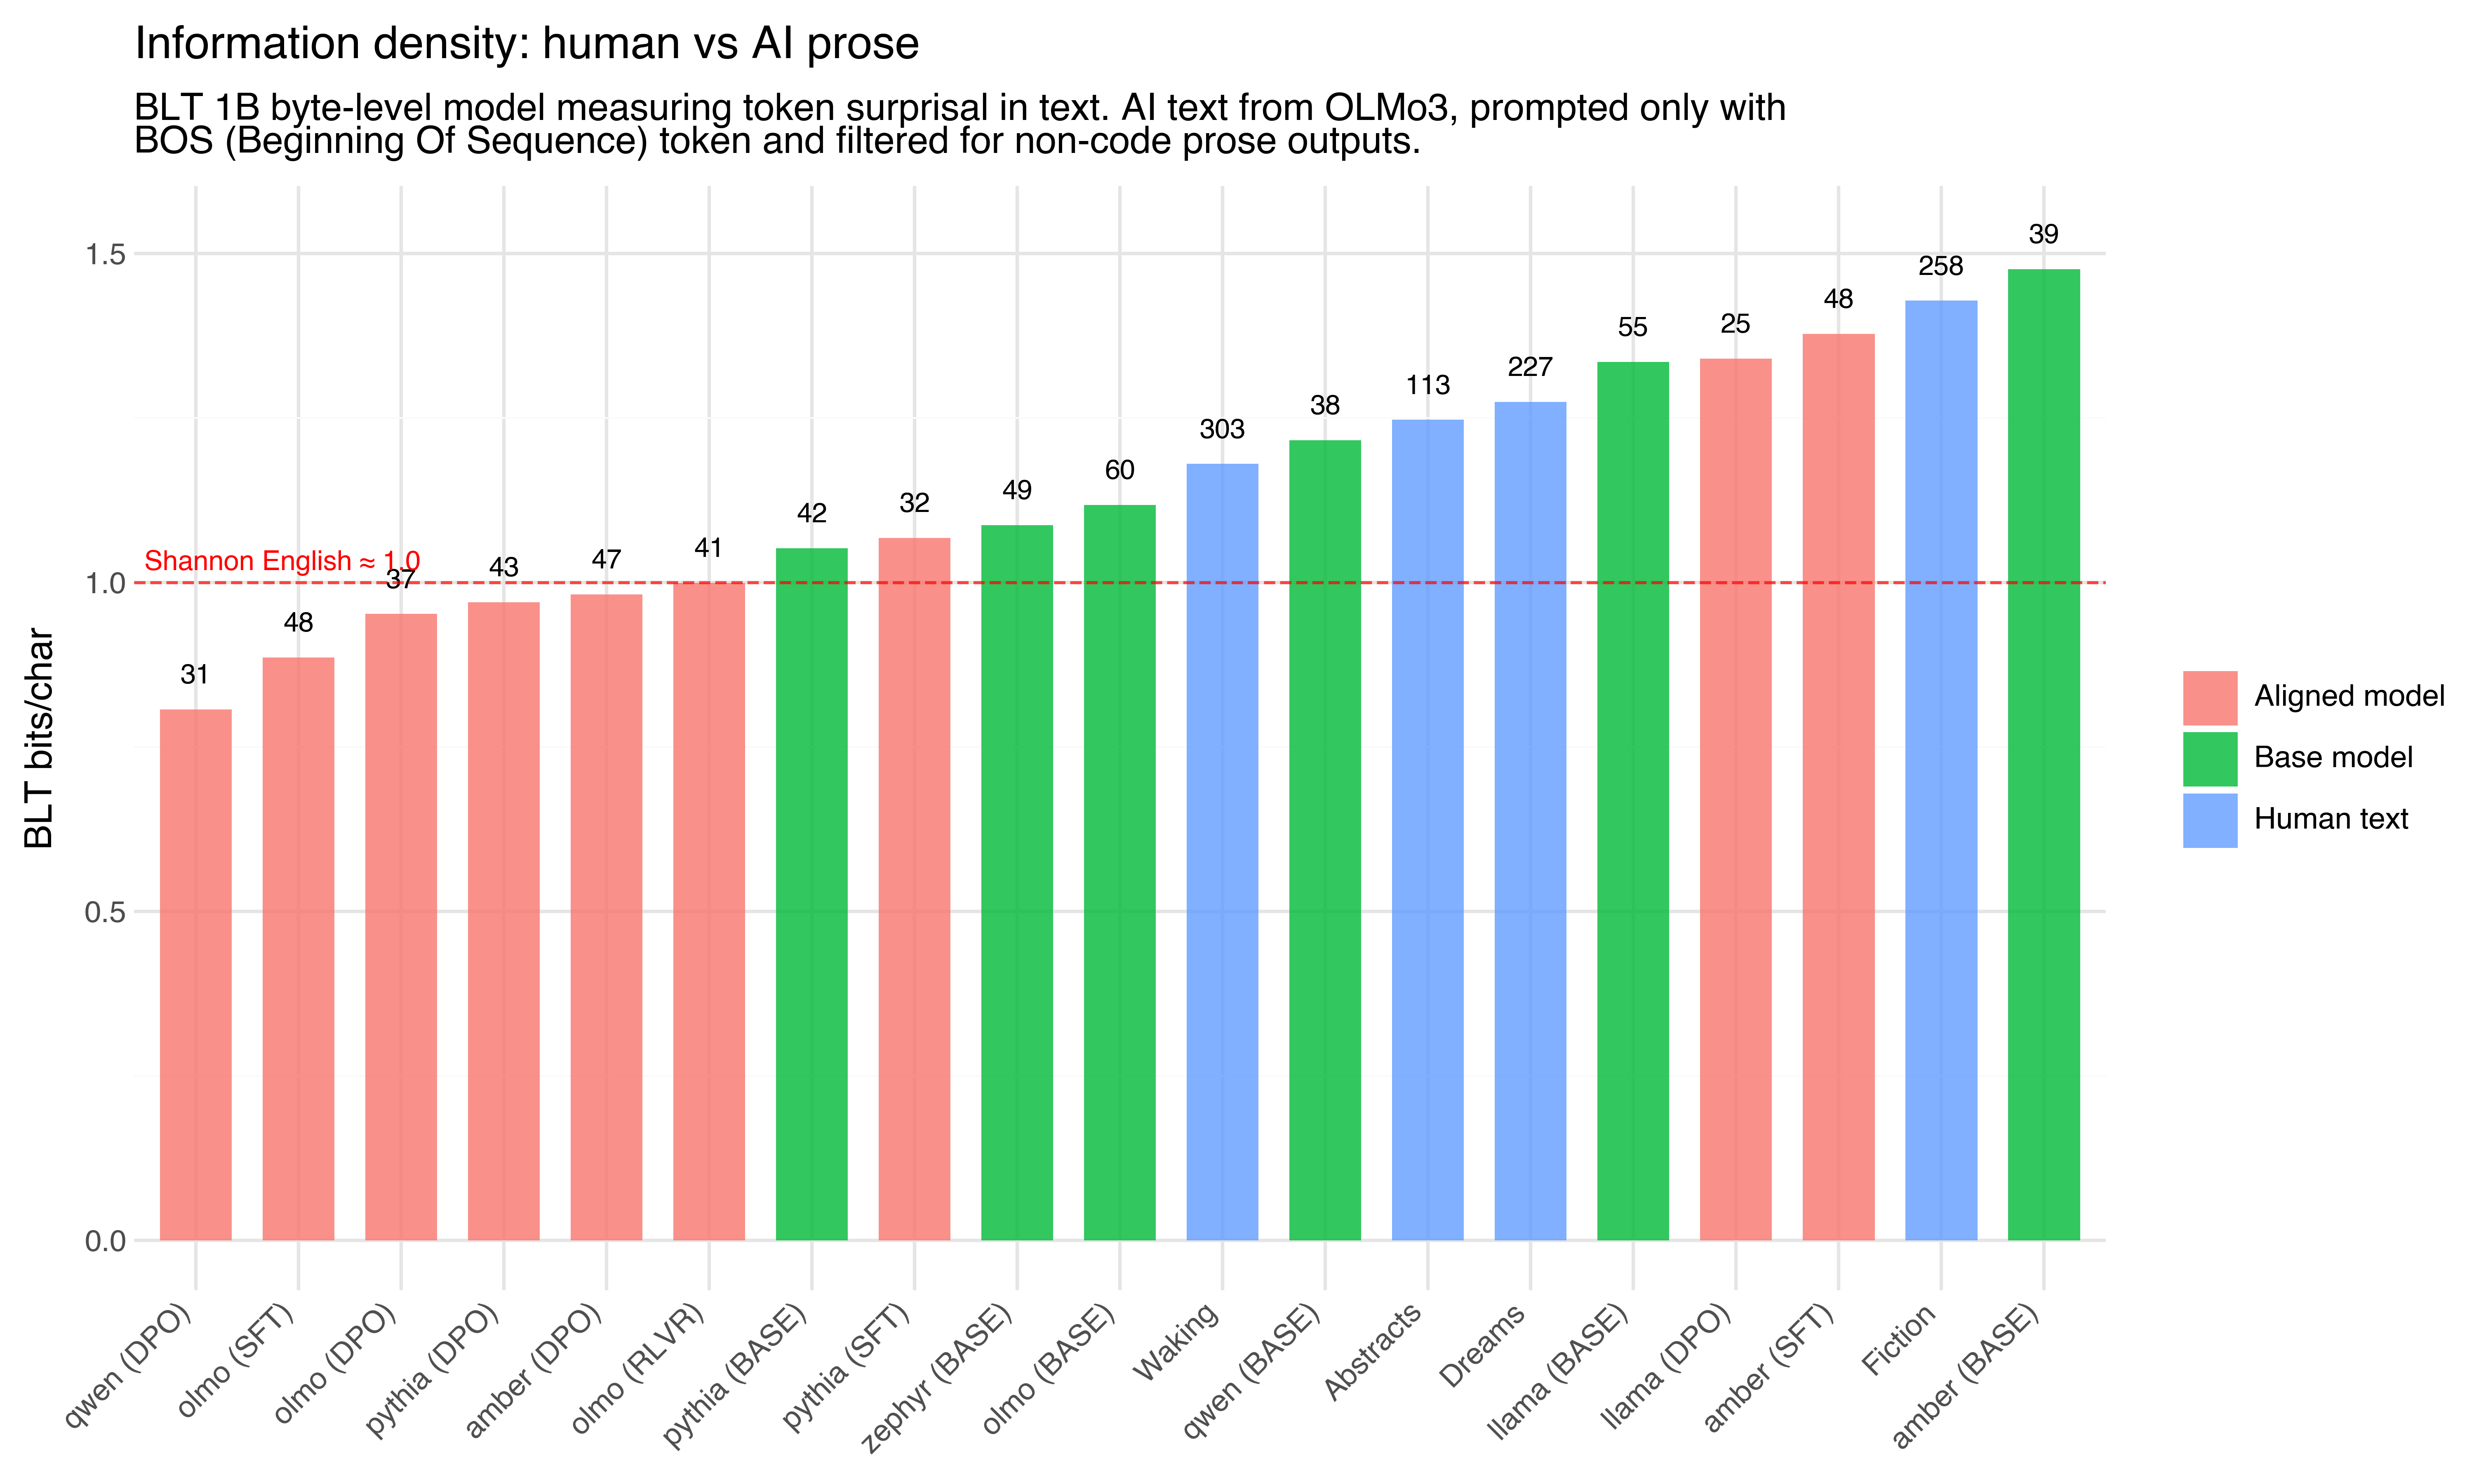

In [151]:
# Combined bar chart: human vs AI (BOS layer means, prose only)
gen_df = pd.read_parquet('../data/generation_analysis.parquet')
gen_df = gen_df[~gen_df.family.isin({'olmo-tiny','qwen-tiny','smol'})]
bos_prose = gen_df[(gen_df.prompt_type == 'bos') & (gen_df.genre == 'prose')].dropna(subset=['blt_bits_per_char'])
bos_prose['n'] = 1

human_blt['n'] = 1
human_agg = human_blt.groupby('label').agg({'bits_per_char': 'median', 'n': 'sum'}).reset_index()
human_agg['group'] = 'Human text'

layer_means = bos_prose.groupby(['family', 'layer']).agg(
    {'blt_bits_per_char': 'median', 'n': 'sum'}).reset_index()
layer_means['label'] = layer_means['family'] + ' (' + layer_means['layer'].map(LAYER_LABELS) + ')'
layer_means['group'] = layer_means['layer'].map(LAYER_LABELS)
layer_means['group'] = layer_means['group'].map({'BASE':'Base model', 'SFT':'Aligned model', 'DPO':'Aligned model', 'RLVR':'Aligned model'})
layer_means = layer_means.rename(columns={'blt_bits_per_char': 'bits_per_char'})

plot_df = pd.concat([
    human_agg[['label', 'bits_per_char', 'group', 'n']],
    layer_means[['label', 'bits_per_char', 'group', 'n']],
], ignore_index=True)
plot_df = plot_df[plot_df.label != 'tulu (BASE)']
plot_df = plot_df[plot_df['n'] >= 25]
plot_df = plot_df.sort_values('bits_per_char')
plot_df['label'] = pd.Categorical(plot_df['label'],
                                   categories=plot_df['label'].tolist(),
                                   ordered=True)

fig = (
    ggplot(plot_df, aes(x='label', y='bits_per_char', fill='group', label='n'))
    + geom_col(alpha=0.8, width=0.7)
    + geom_text(nudge_y=0.05, size=8)
    + geom_hline(yintercept=SHANNON_ENGLISH, linetype='dashed', color='red', alpha=0.7)
    + annotate('text', x=0.5, y=SHANNON_ENGLISH + 0.03,
               label='Shannon English ≈ 1.0', color='red', size=8, ha='left')
    + labs(x='', y='BLT bits/char',
           title='Information density: human vs AI prose',
           subtitle='BLT 1B byte-level model measuring token surprisal in text. AI text from OLMo3, prompted only with\nBOS (Beginning Of Sequence) token and filtered for non-code prose outputs.',
           fill='')
    + theme_minimal()
    + theme(figure_size=(10, 6),
            axis_text_x=element_text(rotation=45, ha='right'))
)
fig.save('../figures/F19_blt_human_vs_ai_bos_family_layer_prose.png', dpi=300)
fig

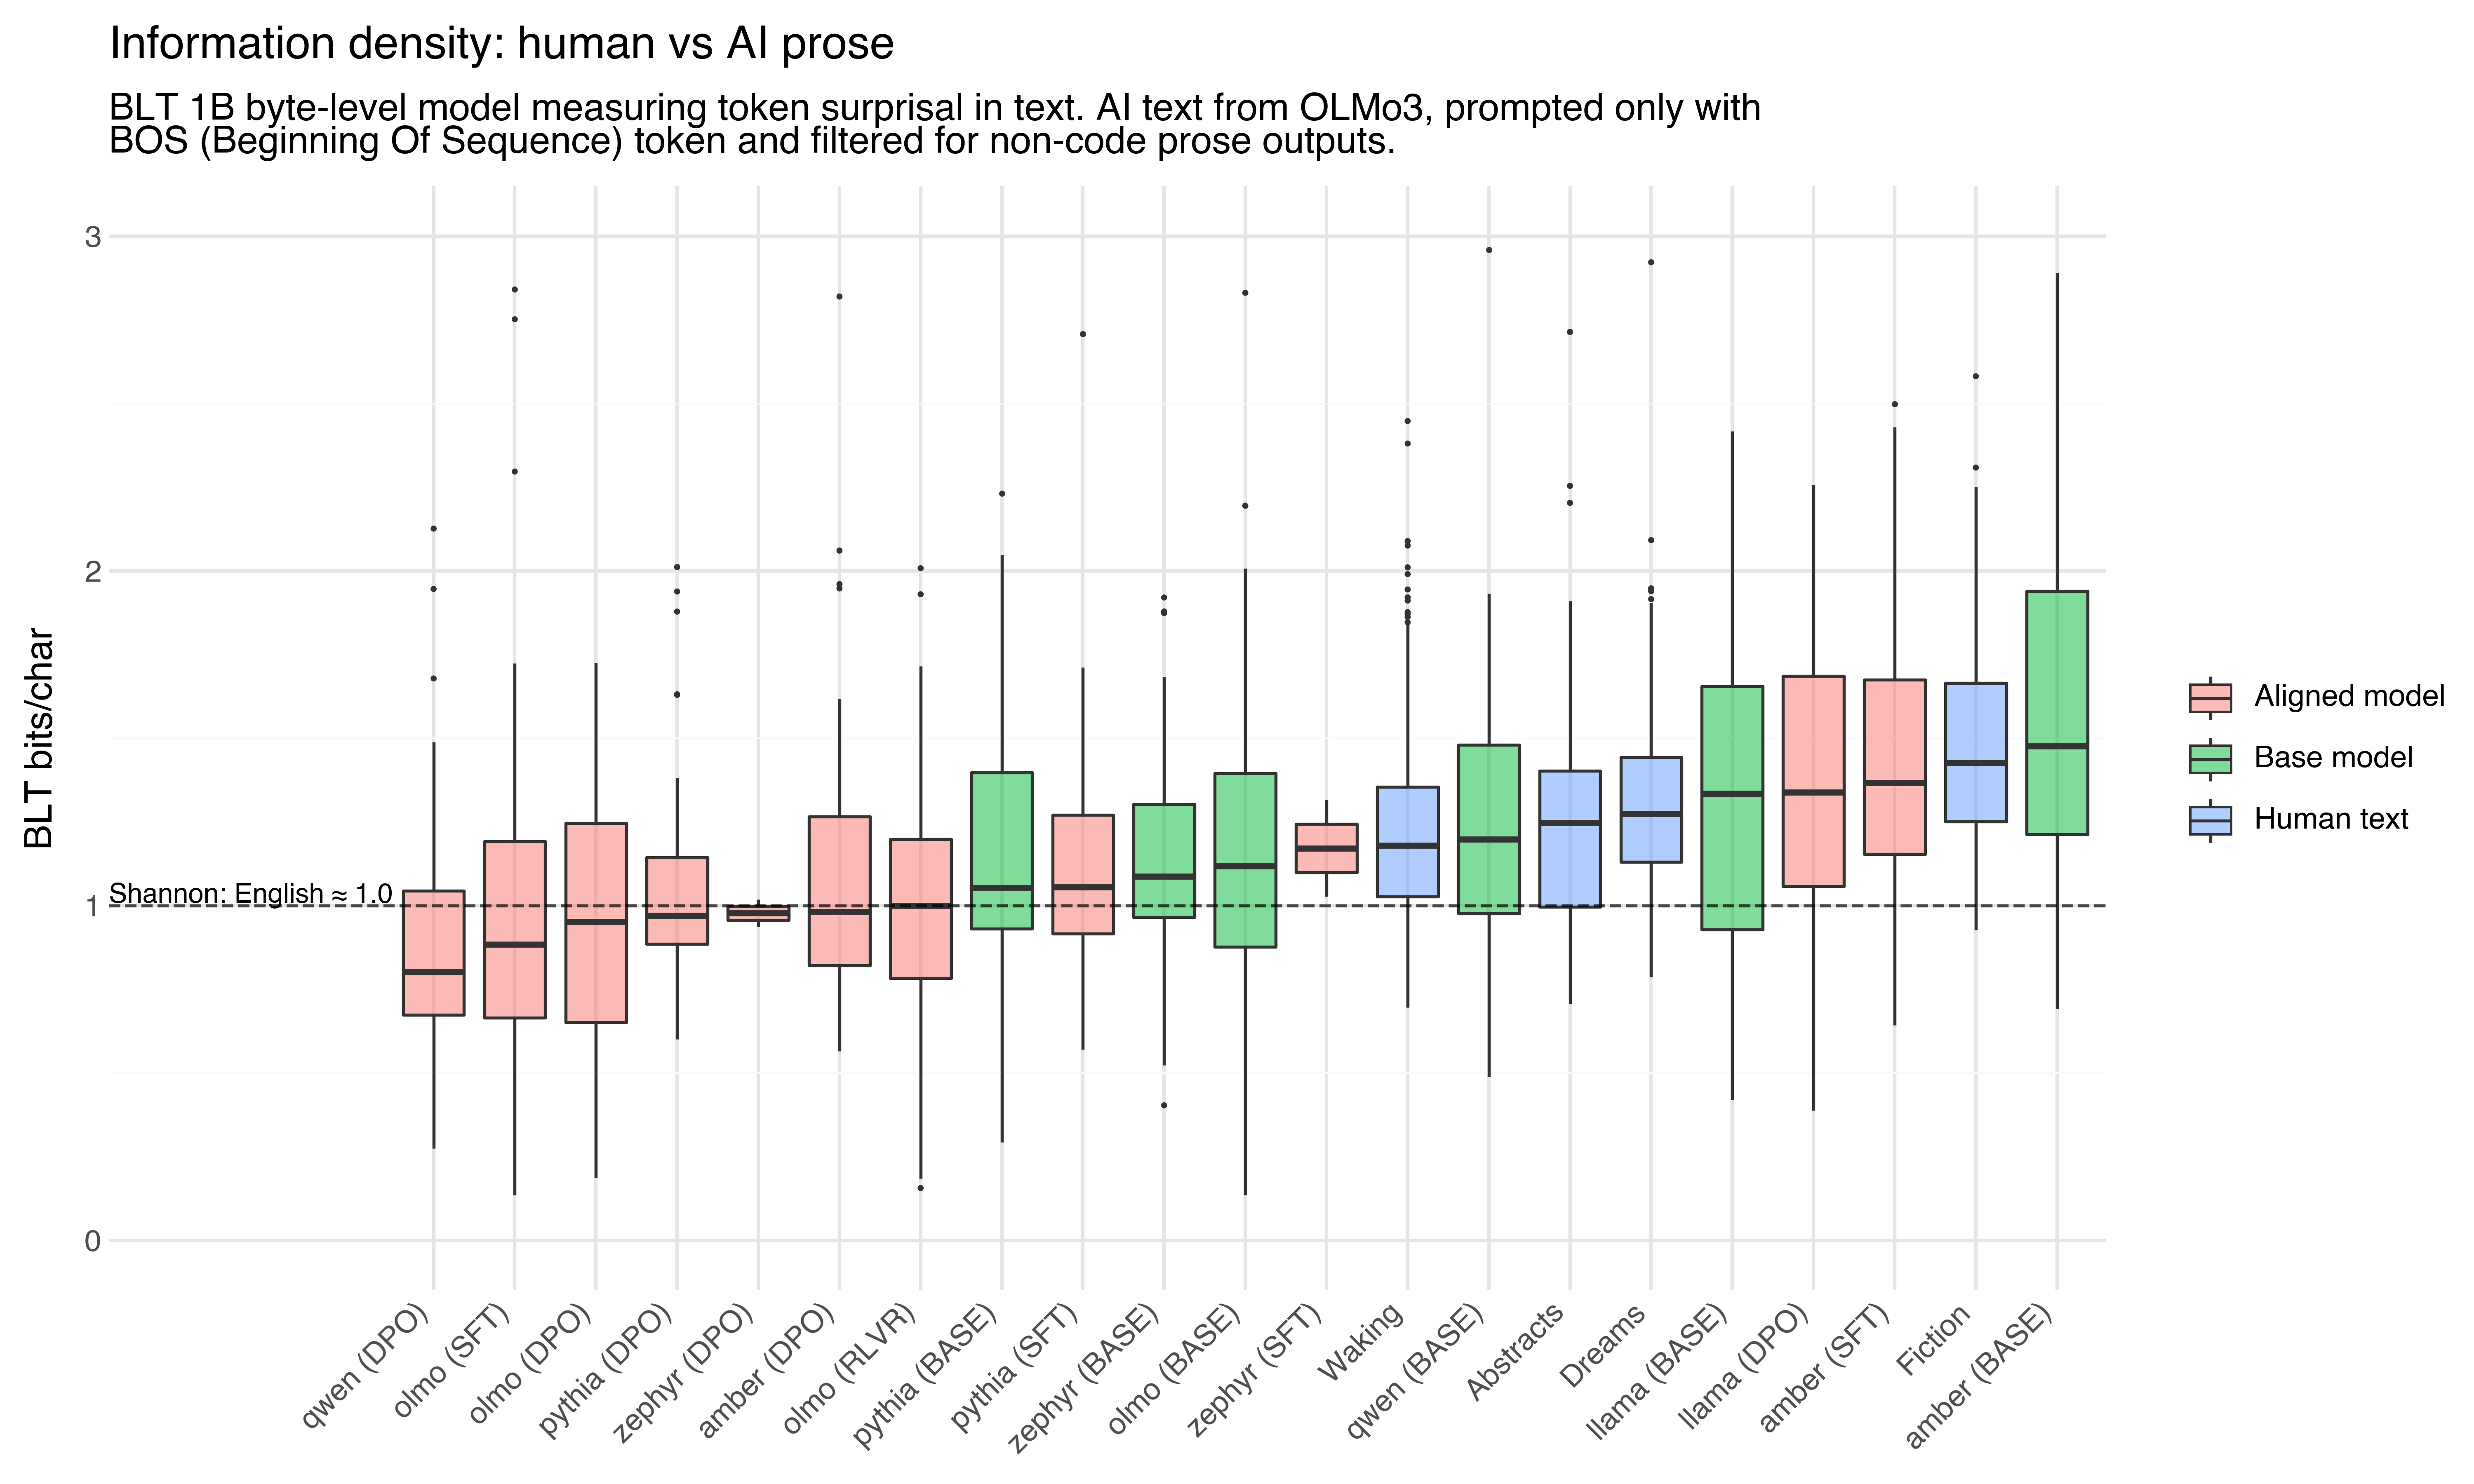

In [165]:
# Combined bar chart: human vs AI (BOS layer means, prose only)
gen_df = pd.read_parquet('../data/generation_analysis.parquet')
gen_df = gen_df[~gen_df.family.isin({'olmo-tiny','qwen-tiny','smol'})]
bos_prose = gen_df[(gen_df.prompt_type == 'bos') & (gen_df.genre == 'prose')].dropna(subset=['blt_bits_per_char'])
bos_prose['n'] = 1

human_blt['n'] = 1
human_agg = human_blt.copy()
human_agg['group'] = 'Human text'

layer_means = bos_prose.copy()
layer_means['label'] = layer_means['family'] + ' (' + layer_means['layer'].map(LAYER_LABELS) + ')'
layer_means['group'] = layer_means['layer'].map(LAYER_LABELS)
layer_means['group'] = layer_means['group'].map({'BASE':'Base model', 'SFT':'Aligned model', 'DPO':'Aligned model', 'RLVR':'Aligned model'})
layer_means = layer_means.rename(columns={'blt_bits_per_char': 'bits_per_char'})

plot_df = pd.concat([
    human_agg[['label', 'bits_per_char', 'group', 'n']],
    layer_means[['label', 'bits_per_char', 'group', 'n']],
], ignore_index=True)
plot_df = plot_df[plot_df.label != 'tulu (BASE)']
# plot_df = plot_df[plot_df['n'] >= 25]
plot_df = plot_df.sort_values('bits_per_char')
order = plot_df.groupby('label').bits_per_char.median().sort_values().index
plot_df['label'] = pd.Categorical(plot_df['label'],
                                   categories=order,
                                   ordered=True)

fig = (
    ggplot(plot_df, aes(x='label', y='bits_per_char', fill='group'))
    + geom_boxplot(outlier_size=0, alpha=.5)
    + geom_hline(yintercept=SHANNON_ENGLISH, linetype='dashed', color='black', alpha=0.7)
    + annotate('text', x=-3, y=SHANNON_ENGLISH + 0.03,
               label='Shannon: English ≈ 1.0', color='black', size=8, ha='left')
    + labs(x='', y='BLT bits/char',
           title='Information density: human vs AI prose',
           subtitle='BLT 1B byte-level model measuring token surprisal in text. AI text from OLMo3, prompted only with\nBOS (Beginning Of Sequence) token and filtered for non-code prose outputs.',
           fill='')
    + theme_minimal()
    + theme(figure_size=(10, 6),
            axis_text_x=element_text(rotation=45, ha='right'))
    + scale_y_continuous(limits=(0, 3))
)
fig.save('../figures/F19_blt_human_vs_ai_bos_family_layer_prose_boxplot.png', dpi=300)
fig

## 5. Private language: self vs reference gap

The gap between self-surprisal and reference surprisal measures how "private" the model's language is. Negative gap = model understands its own output better than an external judge does. Alignment widens this gap for most families.

Self − Ref bits/char gap (BOS): negative = private language
layer       base    ego  instruct  superego
family                                     
amber     -0.164 -0.408       NaN     0.609
llama     -0.303    NaN       NaN    -0.898
olmo      -0.129  0.210     0.255     0.086
olmo-tiny -0.388 -0.402    -0.336    -0.507
pythia    -0.121 -0.097       NaN    -0.102
qwen      -0.668    NaN       NaN    -0.722
qwen-tiny -0.774    NaN       NaN    -0.637
smol      -0.192    NaN       NaN    -0.224
tulu      -0.303    NaN       NaN       NaN
zephyr    -0.187 -0.409       NaN    -0.349


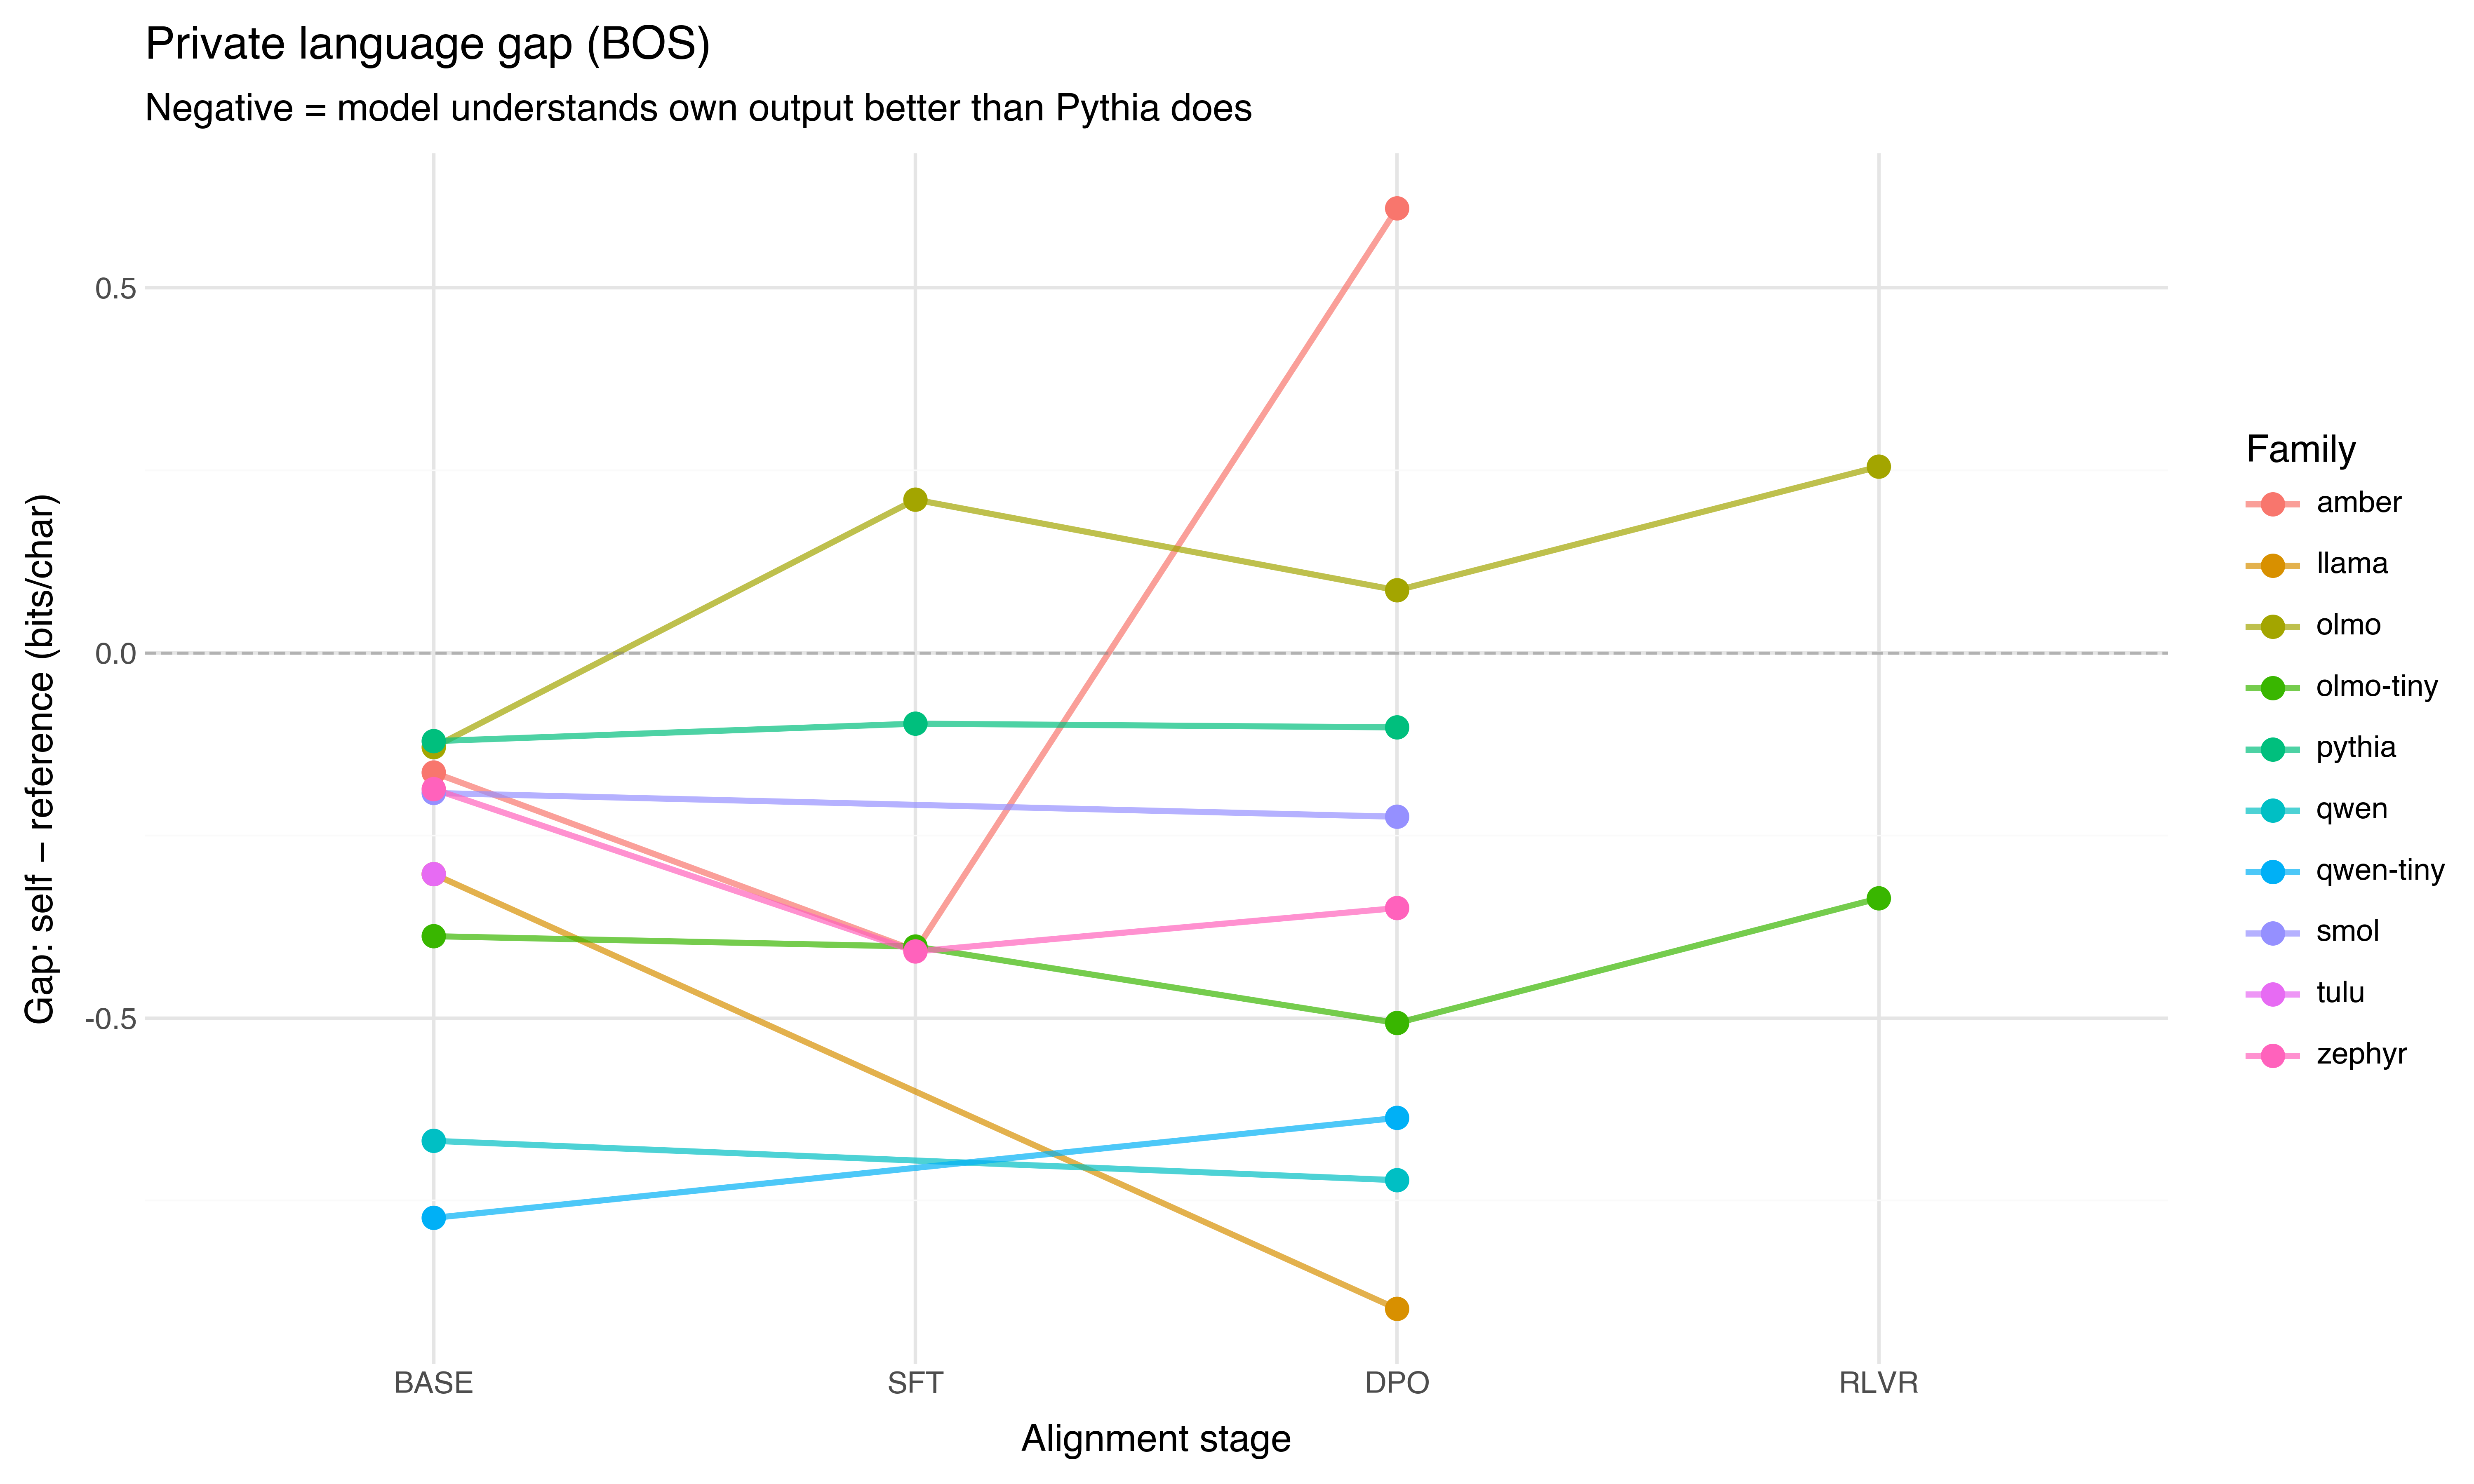

In [139]:
# Self vs Pythia ref gap — BOS
both = valid.dropna(subset=['ref_surprisal', 'ref_bits_per_char']).copy()
both['gap'] = both['self_bits_per_char'] - both['ref_bits_per_char']

bos_both = both[both.prompt_type == 'bos']
print('Self − Ref bits/char gap (BOS): negative = private language')
print('='*60)
pt = bos_both.pivot_table(values='gap', index='family', columns='layer', aggfunc='mean')
print(pt.round(3).to_string())

gap_agg = bos_both.groupby(['family', 'layer']).gap.mean().reset_index()
gap_agg['stage'] = pd.Categorical(
    gap_agg['layer'].map(LAYER_LABELS),
    categories=['BASE', 'SFT', 'DPO', 'RLVR'], ordered=True)

fig = (
    ggplot(gap_agg.dropna(subset=['stage']),
            aes(x='stage', y='gap', group='family', color='family'))
    + geom_line(size=1, alpha=0.7)
    + geom_point(size=3)
    + geom_hline(yintercept=0, linetype='dashed', color='grey', alpha=0.5)
    + labs(x='Alignment stage',
            y='Gap: self − reference (bits/char)',
            title='Private language gap (BOS)',
            subtitle='Negative = model understands own output better than Pythia does',
            color='Family')
    + theme_minimal()
    + theme(figure_size=(10, 6))
)
fig.save('../figures/F19_private_language_gap.png', dpi=300)
fig

## 6. Shannon's communication model applied to alignment

```
INFORMATION SOURCE → TRANSMITTER → [NOISE] → RECEIVER → DESTINATION
   (model weights)    (sampling)   (alignment)  (reader)    (user)
```

In Shannon's framework, noise is what transforms the signal between transmission and reception. Alignment is noise in this precise sense: it intervenes between the base model's distribution and what comes out, reducing channel capacity, increasing redundancy.

The twist: Shannon's noise is unwanted. Alignment noise is *desired*. But it has the same informational consequence — the channel narrows. The question is whether what alignment removes was signal or noise from the perspective of cultural production.

## 7. Summary tables

In [140]:
# Summary: self bits/char across all conditions
for prompt_type, label in [('bos', 'BOS'), ('the', '"The"'), ('battery', 'Battery')]:
    sub = valid[valid.prompt_type == prompt_type]
    if len(sub) == 0:
        continue
    print(f'\nSelf bits/char: {label} by family × layer (Shannon ≈ 1.0)')
    print('='*60)
    pt = sub.pivot_table(values='self_bits_per_char', index='family', columns='layer', aggfunc='mean')
    print(pt.round(3).to_string())

# Genre effect
print(f'\n\nSelf bits/char by genre × layer (BOS)')
print('='*60)
bos_v = valid[valid.prompt_type == 'bos']
pt = bos_v.pivot_table(values='self_bits_per_char', index='layer', columns='genre', aggfunc='mean')
print(pt.round(3).to_string())

# Perplexity (effective choices) for intuition
print(f'\n\nPerplexity (effective choices per token) — BOS prose by family × layer')
print('='*60)
bos_prose_v = valid[(valid.prompt_type == 'bos') & (valid.genre == 'prose')]
pt = bos_prose_v.pivot_table(values='self_surprisal', index='family', columns='layer',
                              aggfunc=lambda x: np.exp(x.mean()))
print(pt.round(1).to_string())


Self bits/char: BOS by family × layer (Shannon ≈ 1.0)
layer       base    ego  instruct  superego
family                                     
amber      1.265  0.977       NaN     1.518
llama      0.750    NaN       NaN     1.094
olmo       0.982  1.149     1.143     1.016
olmo-tiny  0.537  1.133     0.653     0.785
pythia     0.603  0.601       NaN     0.581
qwen       0.720    NaN       NaN     0.396
qwen-tiny  0.979    NaN       NaN     0.686
smol       0.809    NaN       NaN     0.593
tulu       0.750    NaN       NaN       NaN
zephyr     0.776  2.986       NaN     1.682

Self bits/char: "The" by family × layer (Shannon ≈ 1.0)
layer       base    ego  instruct  superego
family                                     
amber      1.059  0.735       NaN     1.439
llama      0.489    NaN       NaN     0.318
olmo       0.636  0.818     0.851     0.737
olmo-tiny  0.694  0.544     0.542     0.640
pythia     0.671  0.616       NaN     0.589
qwen       0.271    NaN       NaN     0.177
qwen-tin

## 8. Export finding to findings/

In [141]:
# !pip install tabulate
# Build the finding markdown
# Tables use current data; figures use ../figures paths (correct from findings/)

# Self bits/char BOS prose table
bos_prose_pt = valid[(valid.prompt_type == 'bos') & (valid.genre == 'prose')].pivot_table(
    values='self_bits_per_char', index='family', columns='layer', aggfunc='mean').round(3)

# Battery table
bat_pt = valid[valid.prompt_type == 'battery'].pivot_table(
    values='self_bits_per_char', index='family', columns='layer', aggfunc='mean').round(3)

# Human BLT table
human_tbl = human_blt.groupby('source').bits_per_char.agg(['mean', 'std']).round(3)

md = f"""# F19: Unconditional Generation & Information Density

## Finding

Alignment compresses the model's unconditional output below Shannon's English entropy rate (~1.0 bits/char), as measured by an independent byte-level model (BLT 1B). All human text types (fiction, dreams, waking reports, abstracts) remain above this threshold. When prompted, the pattern reverses: alignment *increases* cross-entropy, producing text that is more predictable to itself but more opaque to external models ("private language").

## Method

1. Generate 100 completions per layer from BOS token only (no prompt) across 10 model families
2. Classify generations by genre (code, exam, prose, template, math) and language
3. Compute self-surprisal (model scoring own output) and reference surprisal (Pythia 1B, BLT 1B)
4. Convert to bits/char using exact character counts per token
5. Compare against human corpora (dreams, fiction, waking reports, academic abstracts)

Shannon's 1.0 bits/char (1951) is the standard reference for English entropy. Self-surprisal is the exact source entropy rate (model is the source). BLT cross-entropy is an upper bound measured by an independent byte-level judge.

## Key results

**Aligned BOS output is sub-Shannon.** SFT: 0.93 bits/char, DPO: 0.96 — below the 1.0 threshold. Confirmed by both self-surprisal and independent BLT scoring.

**All human text is supra-Shannon.** Fiction: 1.49, Dreams: 1.32, Abstracts: 1.28, Waking: 1.24 bits/char (BLT).

**Battery prompts reverse the direction.** On prompted text, alignment *increases* BLT surprisal (base 1.42 → SFT 1.55). The displacement/swerve effect: aligned models substitute unexpected continuations that are fluent to themselves but surprising to external models.

**Genre confound is real but controllable.** Code (0.56 bits/char) and template (3.07) have very different information densities. Prose-only analysis preserves all findings.

**BOS generation reveals family-specific "resting states."** OLMo SFT defaults to chat templates ("You are a helpful function-calling AI assistant"). Llama Instruct defaults to Chinese medical exam questions. Qwen base is 43% exam questions (pre-socialised). Each family finds a different attractor.

**Alignment compression is content-independent on battery prompts.** All 9 content categories (sexual, violent, neutral, etc.) compress from ~1.0 to ~0.7 bits/char. The delta is uniform (Kruskal-Wallis p=0.99 on per-family deltas).

**Amber anomaly confirmed.** AmberSafe (DPO) has *higher* self-surprisal than base (1.56 vs 1.29 bits/char). The safety model surprises itself — unique across all families.

## Figures

![Human vs AI information density](../figures/F19_blt_human_vs_ai_bos.png)

![BOS genre distribution](../figures/F19_bos_genre_distribution.png)

![Self-surprisal BOS prose](../figures/F19_self_surprisal_bos_prose.png)

![Self-surprisal battery by category](../figures/F19_self_surprisal_battery_category.png)

![Private language gap](../figures/F19_private_language_gap.png)

## Shannon's communication model

```
INFORMATION SOURCE → TRANSMITTER → [NOISE] → RECEIVER → DESTINATION
   (model weights)    (sampling)   (alignment)  (reader)    (user)
```

Alignment is noise in Shannon's precise sense: it transforms the signal between source and reception, reducing channel capacity and increasing redundancy. The twist is that this noise is desired — but it has the same informational consequence as unwanted interference.

## Self bits/char: BOS prose only (Shannon ≈ 1.0)

{bos_prose_pt.to_markdown()}

## Self bits/char: battery prompts (Shannon ≈ 1.0)

{bat_pt.to_markdown()}

## BLT bits/char: human corpora

{human_tbl.to_markdown()}

## Data

- `data/generation_analysis.parquet` — 141k generations with genre, self/ref surprisal, bits/char
- `data/blt_human_corpora.csv` — BLT scores for dreams, fiction, waking, abstracts
- `data/blt_combined.csv` — combined human + AI BLT scores
- Generation cache: `data/raw/cache/generations/`
- Surprisal caches: `data/raw/cache/self_surprisal/`, `data/raw/cache/ref_surprisal/`

## Notebook

`notebooks/F19_bos_entropy.ipynb`

## CLI

```bash
malign bos-generate --family olmo --n 100          # generate from BOS
malign bos-generate --prompt "The" --n 100         # generate from custom prompt
malign surprisal --self                             # self-surprisal for all cached generations
malign surprisal --ref itazap/blt-1b-hf            # BLT byte-level reference surprisal
```
"""

out_path = '../findings/F19_bos_entropy.md'
with open(out_path, 'w') as f:
    f.write(md)
print(f'Wrote {out_path} ({len(md)} chars)')

Wrote ../findings/F19_bos_entropy.md (6000 chars)
